# Supplementary 4 — Independent testing and ecological application

This notebook applies the final BoutScout BiLSTM (5-feature schema) to an
independent set of nest-temperature recordings, exports daily plots for manual
quality control, and computes the behavioural and ecological summaries used in
the manuscript.

The pipeline is linear:

1. Setup, paths, model schema and weights.
2. Schema-driven minute-level inference on each test recording.
3. Diagnostic post-processing of suspicious short-Nocturnal events.
4. A single switch (`PREDICTION_LAYER_FOR_ECOLOGY`) chooses whether the
   downstream ecological summaries use raw or post-processed predictions.
5. Daily plots are exported in the original visual style; the manuscript uses
   a manually curated subset of those plots stored under
   `D:/Thesis/figures/testing/tangara_2/selected`.
6. Selected days feed the legacy ecological summaries: events, nest
   attentiveness, Tangara metadata, PCA / KMeans, and species comparisons.

Throughout the notebook, behavioural classes are encoded as
`{0: Nocturnal, 1: Off, 2: On}` with colours
`{0: #333E48, 1: #535AA6, 2: #E28342}`.


## A. Setup, paths and feature schema

Imports, GPU validation, the canonical class colours, and the paths used by
every later section. The feature schema is loaded from
`API/feature_schema.json` so the inference engine and the trained weights stay
in sync.


In [312]:

import os
import pandas as pd
import glob
import torch
import numpy as np
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import matplotlib.pyplot as plt
import sys
print(sys.executable)

C:\Users\jorge\AppData\Local\Programs\Python\Python310\python.exe


In [313]:
# === GPU validation — must run before any training/inference ===
import torch

print("Torch version:", torch.__version__)
print("Torch CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available. Stop. Do not train on CPU. "
                       "Install a CUDA 12.8 PyTorch build: "
                       "pip install torch --index-url https://download.pytorch.org/whl/cu128")

print("GPU:", torch.cuda.get_device_name(0))
print("Compute capability:", torch.cuda.get_device_capability(0))

_x = torch.randn(2048, 2048, device="cuda")
_y = _x @ _x
torch.cuda.synchronize()
print("CUDA tensor test passed:", _y.shape)
del _x, _y
torch.cuda.empty_cache()


Torch version: 2.11.0+cu128
Torch CUDA version: 12.8
CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Laptop GPU
Compute capability: (12, 0)
CUDA tensor test passed: torch.Size([2048, 2048])


In [314]:
# === Feature schema — single source of truth ===
import json
from pathlib import Path

_FS_PATH = Path("API/feature_schema.json")
with open(_FS_PATH, "r", encoding="utf-8") as _f:
    feature_schema = json.load(_f)

LABEL_MAP = {int(k): v for k, v in feature_schema["label_map"].items()}
ACTIVE_FEATURES = feature_schema["features"]
INPUT_SIZE = int(feature_schema["input_size"])
SEQUENCE_LENGTH = int(feature_schema["sequence_length"])
HIDDEN_SIZE = int(feature_schema["model_config"]["hidden_size"])
NUM_LAYERS = int(feature_schema["model_config"]["num_layers"])
NUM_CLASSES = int(feature_schema["model_config"]["num_classes"])

assert len(ACTIVE_FEATURES) == INPUT_SIZE, "feature_schema: len(features) != input_size"
print(f"Active model: {feature_schema['active_model']}")
print(f"Features ({INPUT_SIZE}): {ACTIVE_FEATURES}")
print(f"Label map: {LABEL_MAP}")


Active model: Model_C_time_scaled
Features (5): ['egg_temperature', 'ambient_temperature', 'hour_sin', 'hour_cos', 'minute_of_day_scaled']
Label map: {0: 'Nocturnal', 1: 'Off', 2: 'On'}


In [315]:
# Active paths and the canonical class colours used by every figure.
TEST_FOLDER = r"D:/Thesis/Testting/tangara"
SELECTED_DAY_DIR = r"D:/Thesis/figures/testing/tangara_2/selected"
OUTPUT_DAY_PLOT_DIR = "figures/supplementary4/day_plots_for_selection"
ACTIVE_INFERENCE_PATH = "resultados_supplementary4_inference.csv"
FILTERED_SELECTED_PATH = "resultados_filtrados_2.csv"

COLORS = {0: "#333E48", 1: "#535AA6", 2: "#E28342"}
LABELS = {0: "Nocturnal", 1: "Off", 2: "On"}

from pathlib import Path
Path(OUTPUT_DAY_PLOT_DIR).mkdir(parents=True, exist_ok=True)
print("TEST_FOLDER          :", TEST_FOLDER)
print("SELECTED_DAY_DIR     :", SELECTED_DAY_DIR)
print("OUTPUT_DAY_PLOT_DIR  :", OUTPUT_DAY_PLOT_DIR)
print("ACTIVE_INFERENCE_PATH:", ACTIVE_INFERENCE_PATH)
print("FILTERED_SELECTED_PATH:", FILTERED_SELECTED_PATH)


TEST_FOLDER          : D:/Thesis/Testting/tangara
SELECTED_DAY_DIR     : D:/Thesis/figures/testing/tangara_2/selected
OUTPUT_DAY_PLOT_DIR  : figures/supplementary4/day_plots_for_selection
ACTIVE_INFERENCE_PATH: resultados_supplementary4_inference.csv
FILTERED_SELECTED_PATH: resultados_filtrados_2.csv


## B. Model class and weight loading

The BiLSTM uses the architecture defined in the training notebooks
(S1 / S2 / S3) and the weight file selected for the manuscript
(`API/model_final_bilstm_state_dict.pth`, fallback
`modelo_fi_total/modelo_entrenado_final_total.pth`). The cell asserts that the
loaded schema matches the trained 5-feature model.


In [316]:
import json, torch, torch.nn as nn
from pathlib import Path

if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

COLORS = {0: "#333E48", 1: "#535AA6", 2: "#E28342"}
LABELS = {0: "Nocturnal", 1: "Off", 2: "On"}
EXPECTED_FEATURES = [
    "egg_temperature",
    "ambient_temperature",
    "hour_sin",
    "hour_cos",
    "minute_of_day_scaled",
]

class BiLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(BiLSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
        )
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out)
        return out

with open("API/feature_schema.json", "r", encoding="utf-8") as _f:
    feature_schema = json.load(_f)
with open("API/label_map.json", "r", encoding="utf-8") as _f:
    LABEL_MAP = {int(k): v for k, v in json.load(_f).items()}

ACTIVE_FEATURES = feature_schema["features"]
INPUT_SIZE = int(feature_schema["input_size"])
HIDDEN_SIZE = int(feature_schema["model_config"]["hidden_size"])
NUM_LAYERS = int(feature_schema["model_config"]["num_layers"])
NUM_CLASSES = int(feature_schema["model_config"]["num_classes"])
SEQUENCE_LENGTH = int(feature_schema["sequence_length"])

assert ACTIVE_FEATURES == EXPECTED_FEATURES, f"Unexpected feature order: {ACTIVE_FEATURES}"
assert INPUT_SIZE == 5, f"Expected input_size=5, found {INPUT_SIZE}"
assert len(ACTIVE_FEATURES) == INPUT_SIZE

_pth_api = Path("API/model_final_bilstm_state_dict.pth")
_pth_legacy = Path("modelo_fi_total/modelo_entrenado_final_total.pth")
MODEL_PATH = _pth_api if _pth_api.exists() else _pth_legacy
if not MODEL_PATH.exists():
    raise FileNotFoundError("No trained BiLSTM weights found in API/ or modelo_fi_total/.")

modelo_final = BiLSTMModel(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
)
modelo_final.load_state_dict(torch.load(MODEL_PATH, map_location=device))
modelo_final.to(device)
modelo_final.eval()

print("Device            :", device)
print("Model loaded from :", MODEL_PATH)
print("Active features   :", ACTIVE_FEATURES)
print("Input size        :", INPUT_SIZE)
print("Hidden size       :", HIDDEN_SIZE, "| layers:", NUM_LAYERS, "| classes:", NUM_CLASSES)
print("Label map         :", LABEL_MAP)

Device            : cuda
Model loaded from : API\model_final_bilstm_state_dict.pth
Active features   : ['egg_temperature', 'ambient_temperature', 'hour_sin', 'hour_cos', 'minute_of_day_scaled']
Input size        : 5
Hidden size       : 64 | layers: 2 | classes: 3
Label map         : {0: 'Nocturnal', 1: 'Off', 2: 'On'}


## C. Schema-driven 5-feature inference

For every CSV in `TEST_FOLDER` we standardise the egg- and ambient-temperature
columns, build the 5-feature input
(`egg_temperature, ambient_temperature, hour_sin, hour_cos, minute_of_day_scaled`),
keep only complete 1440-minute calendar days, and run the BiLSTM. The minute
level output is written to `resultados_supplementary4_inference_raw.csv` (raw
predictions) and `resultados_supplementary4_inference.csv` (active layer used
by the ecological summaries; see Section E).


In [317]:
import numpy as np
import pandas as pd

EGG_CANDIDATES = ["egg_temperature", "egg", "nest", "tempe"]
AMBIENT_CANDIDATES = ["ambient_temperature", "ambient", "ambiente"]
DATETIME_CANDIDATES = ["datetime", "date-time", "date_time", "fecha_hora", "timestamp", "fecha"]


def _first_present(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def standardise_df(df_raw):
    df = df_raw.copy()
    df.columns = [str(c).strip().lower() for c in df.columns]

    egg_col = _first_present(df, EGG_CANDIDATES)
    amb_col = _first_present(df, AMBIENT_CANDIDATES)
    if egg_col is None or amb_col is None:
        return None

    df = df.rename(columns={egg_col: "egg_temperature", amb_col: "ambient_temperature"})

    dt_col = _first_present(df, DATETIME_CANDIDATES)
    if dt_col is not None:
        df["datetime"] = pd.to_datetime(df[dt_col], errors="coerce")
    elif "fecha" in df.columns and "hora" in df.columns:
        df["datetime"] = pd.to_datetime(df["fecha"].astype(str) + " " + df["hora"].astype(str), errors="coerce")
    elif "tiempo" in df.columns:
        base = pd.Timestamp("2000-01-01")
        df["datetime"] = base + pd.to_timedelta(df["tiempo"].astype(float), unit="m")
    else:
        return None

    df = df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)
    df["minute_of_day"] = df["datetime"].dt.hour * 60 + df["datetime"].dt.minute
    return df


def build_features_from_df(df_std, feature_list):
    df = df_std.copy()
    df["hour_sin"] = np.sin(2 * np.pi * df["minute_of_day"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minute_of_day"] / 1440)
    df["minute_of_day_scaled"] = df["minute_of_day"] / 1439.0

    missing = [f for f in feature_list if f not in df.columns]
    if missing:
        raise KeyError(f"Schema features missing after build: {missing}")

    X = df[feature_list].to_numpy(dtype=np.float32)
    assert X.shape[1] == INPUT_SIZE, f"Feature count mismatch: {X.shape[1]} vs {INPUT_SIZE}"
    return X, df

print("Feature builder ready. Active features:", ACTIVE_FEATURES)

Feature builder ready. Active features: ['egg_temperature', 'ambient_temperature', 'hour_sin', 'hour_cos', 'minute_of_day_scaled']


In [318]:
import os, glob
from collections import Counter
from pathlib import Path

PROMETEO_DIR = Path("prometeo"); PROMETEO_DIR.mkdir(exist_ok=True)

def split_into_complete_days(df_std, archivo, *, strict=True, max_missing_for_interp=0):
    """Yield (date, day_df_1440rows) for complete days. Returns also a diagnostics list."""
    diagnostics = []
    if df_std is None or df_std.empty:
        return [], diagnostics

    df = df_std.copy()
    df["date"] = df["datetime"].dt.date

    days = []
    for date, g in df.groupby("date", sort=True):
        original_rows = len(g)
        g = g.drop_duplicates(subset=["minute_of_day"], keep="first")
        unique_minutes = g["minute_of_day"].nunique()
        duplicated_minutes = original_rows - unique_minutes

        full_idx = pd.RangeIndex(0, 1440, name="minute_of_day")
        g_full = g.set_index("minute_of_day").reindex(full_idx)
        missing_minutes = int(g_full["egg_temperature"].isna().sum())

        kept, reason = False, ""
        if strict:
            if unique_minutes == 1440 and missing_minutes == 0:
                kept, reason = True, "complete"
            else:
                reason = f"strict: unique={unique_minutes}, missing={missing_minutes}"
        else:
            if missing_minutes <= max_missing_for_interp:
                g_full = g_full.interpolate("linear", limit_direction="both")
                if g_full[["egg_temperature", "ambient_temperature"]].isna().any().any():
                    reason = "interpolation_failed"
                else:
                    kept, reason = True, f"interpolated:{missing_minutes}"
            else:
                reason = f"too_many_missing:{missing_minutes}"

        diagnostics.append({
            "archivo": archivo, "date": str(date),
            "original_rows": original_rows,
            "unique_minutes": unique_minutes,
            "missing_minutes": missing_minutes,
            "duplicated_minutes": duplicated_minutes,
            "kept_or_removed": "kept" if kept else "removed",
            "reason": reason,
        })

        if kept:
            g_full = g_full.reset_index()
            # Re-synthesise canonical datetime per minute for plotting
            base = pd.Timestamp(date)
            g_full["datetime"] = base + pd.to_timedelta(g_full["minute_of_day"], unit="m")
            days.append((date, g_full))
    return days, diagnostics


In [319]:
TEST_FOLDER = r"D:/Thesis/Testting/tangara"
csv_files = sorted(glob.glob(os.path.join(TEST_FOLDER, "*.csv")))
print(f"Found {len(csv_files)} CSV files in {TEST_FOLDER}")

all_days = []
all_diagnostics = []
files_processed, files_skipped = 0, 0

for path in csv_files:
    archivo = os.path.basename(path)
    try:
        raw = pd.read_csv(path)
    except Exception as e:
        all_diagnostics.append({
            "archivo": archivo,
            "date": "",
            "original_rows": 0,
            "unique_minutes": 0,
            "missing_minutes": 0,
            "duplicated_minutes": 0,
            "kept_or_removed": "removed",
            "reason": f"read_csv_error:{e}",
        })
        files_skipped += 1
        continue

    df_std = standardise_df(raw)
    if df_std is None:
        all_diagnostics.append({
            "archivo": archivo,
            "date": "",
            "original_rows": len(raw),
            "unique_minutes": 0,
            "missing_minutes": 0,
            "duplicated_minutes": 0,
            "kept_or_removed": "removed",
            "reason": "missing_essential_columns",
        })
        files_skipped += 1
        continue

    days, diag = split_into_complete_days(df_std, archivo, strict=True)
    all_diagnostics.extend(diag)
    files_processed += 1

    for date, day_df in days:
        _, day_df_full = build_features_from_df(day_df, ACTIVE_FEATURES)
        assert day_df_full[ACTIVE_FEATURES].shape == (SEQUENCE_LENGTH, INPUT_SIZE)
        day_df_full["archivo"] = archivo
        day_df_full["date"] = pd.to_datetime(date).date()
        all_days.append((archivo, date, day_df_full))

diag_df = pd.DataFrame(all_diagnostics)
diag_df.to_csv(PROMETEO_DIR / "supplementary4_day_blocking_QA.csv", index=False)

days_detected = len(diag_df)
n_kept = int((diag_df["kept_or_removed"] == "kept").sum())
n_removed = int((diag_df["kept_or_removed"] == "removed").sum())
removal_pct = (100.0 * n_removed / days_detected) if days_detected else 0.0

print(f"Files processed : {files_processed} (skipped {files_skipped})")
print(f"Days detected   : {days_detected}")
print(f"Days kept       : {n_kept}")
print(f"Days removed    : {n_removed}")
print(f"Removal percent : {removal_pct:.1f}%")
if n_removed:
    print("Top removal reasons:")
    for reason, k in Counter(d["reason"] for d in all_diagnostics if d["kept_or_removed"] == "removed").most_common(5):
        print(f"  {k:6d}  {reason}")

if removal_pct > 40.0:
    raise RuntimeError(f"Strict day filtering removed {removal_pct:.1f}% of detected days. Review before continuing.")

Found 69 CSV files in D:/Thesis/Testting/tangara


C:\Users\jorge\AppData\Local\Temp\ipykernel_6812\2218537358.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["datetime"] = pd.to_datetime(df[dt_col], errors="coerce")
C:\Users\jorge\AppData\Local\Temp\ipykernel_6812\2218537358.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["datetime"] = pd.to_datetime(df[dt_col], errors="coerce")
C:\Users\jorge\AppData\Local\Temp\ipykernel_6812\2218537358.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["datetime"] = pd.to_datetime(df[dt_col], errors="coerce")
C:\Users\jorge\AppData\Local\Temp\ipykernel_6812\221853735

Files processed : 69 (skipped 0)
Days detected   : 424
Days kept       : 286
Days removed    : 138
Removal percent : 32.5%
Top removal reasons:
       5  strict: unique=899, missing=541
       3  strict: unique=479, missing=961
       3  strict: unique=959, missing=481
       3  strict: unique=839, missing=601
       3  strict: unique=1002, missing=438


In [320]:
from torch.utils.data import DataLoader, TensorDataset

inv_label = {v: k for k, v in LABEL_MAP.items()}

if not all_days:
    raise RuntimeError("No complete days passed QA. Inspect prometeo/supplementary4_day_blocking_QA.csv.")

X_arr = np.stack([
    build_features_from_df(d.drop(columns=[c for c in ["archivo", "date"] if c in d.columns]), ACTIVE_FEATURES)[0]
    for _, _, d in all_days
], axis=0)
assert X_arr.shape[1] == SEQUENCE_LENGTH and X_arr.shape[2] == INPUT_SIZE
assert X_arr[0].shape == (SEQUENCE_LENGTH, INPUT_SIZE)
print("Inference tensor shape:", X_arr.shape)

X_t = torch.from_numpy(X_arr).float()
loader = DataLoader(TensorDataset(X_t), batch_size=16, shuffle=False, pin_memory=True, num_workers=0)

probs_all, preds_all, hidden_all = [], [], []
modelo_final.eval()
with torch.no_grad():
    for (xb,) in loader:
        xb = xb.to(device, non_blocking=True)
        lstm_out, _ = modelo_final.lstm(xb)
        logits = modelo_final.fc(lstm_out)
        probs = torch.softmax(logits, dim=2)
        preds = torch.argmax(probs, dim=2)
        probs_all.append(probs.cpu().numpy())
        preds_all.append(preds.cpu().numpy())
        hidden_all.append(lstm_out.cpu().numpy())

probs_all = np.concatenate(probs_all, axis=0)
preds_all = np.concatenate(preds_all, axis=0)
hidden_all = np.concatenate(hidden_all, axis=0)

assert preds_all.shape == (len(all_days), 1440)
assert set(np.unique(preds_all)).issubset({0, 1, 2})

minute_rows = []
for i, (archivo, date, day_df) in enumerate(all_days):
    p = preds_all[i]
    pr = probs_all[i]
    minute_rows.append(pd.DataFrame({
        "archivo": archivo,
        "date": pd.to_datetime(date).date(),
        "dia_index": i,
        "minute_of_day": np.arange(1440),
        "minute_of_day_scaled": day_df["minute_of_day_scaled"].values,
        "hour_sin": day_df["hour_sin"].values,
        "hour_cos": day_df["hour_cos"].values,
        "datetime": day_df["datetime"].values,
        "egg_temperature": day_df["egg_temperature"].values,
        "ambient_temperature": day_df["ambient_temperature"].values,
        "prediccion": p.astype(int),
        "prediccion_label": [LABEL_MAP[int(v)] for v in p],
        "prob_nocturnal": pr[:, 0],
        "prob_off": pr[:, 1],
        "prob_on": pr[:, 2],
    }))

inference_df = pd.concat(minute_rows, ignore_index=True)
inference_df.to_csv("resultados_supplementary4_inference.csv", index=False)
print("Inference dataframe:", inference_df.shape, "→ resultados_supplementary4_inference.csv")
print(inference_df.head(3))

Inference tensor shape: (286, 1440, 5)
Inference dataframe: (411840, 15) → resultados_supplementary4_inference.csv
                                            archivo        date  dia_index  \
0  Myrmotherula_hauxwelli_P02a_AJRC13_processed.csv  2013-09-12          0   
1  Myrmotherula_hauxwelli_P02a_AJRC13_processed.csv  2013-09-12          0   
2  Myrmotherula_hauxwelli_P02a_AJRC13_processed.csv  2013-09-12          0   

   minute_of_day  minute_of_day_scaled  hour_sin  hour_cos  \
0              0              0.000000  0.000000  1.000000   
1              1              0.000695  0.004363  0.999990   
2              2              0.001390  0.008727  0.999962   

             datetime  egg_temperature  ambient_temperature  prediccion  \
0 2013-09-12 00:00:00           33.209               22.705           0   
1 2013-09-12 00:01:00           33.209               22.633           0   
2 2013-09-12 00:02:00           33.209               22.609           0   

  prediccion_label  pr

## D. Diagnostic event extraction and post-processing

We extract every behavioural event from the raw predictions, flag suspicious
short-Nocturnal episodes that overlap full daylight or are wedged between two
long On bouts, and apply a documented set of post-processing rules. Both the
raw and post-processed event tables are saved so that the manuscript can audit
the corrections.


In [321]:
def extract_events_from_prediction(g, prediction_col="prediccion", state_col="state", state_label_col="state_label"):
    """Return an event dataframe from a per-day minute dataframe sorted by minute_of_day."""
    pred = g[prediction_col].to_numpy()
    minute = g["minute_of_day"].to_numpy()
    if len(pred) == 0:
        return pd.DataFrame()

    change = np.where(np.diff(pred) != 0)[0] + 1
    starts = np.concatenate([[0], change])
    ends = np.concatenate([change, [len(pred)]])
    rows = []
    for k, (s, e) in enumerate(zip(starts, ends)):
        seg = g.iloc[s:e]
        rows.append({
            "archivo": g["archivo"].iloc[0],
            "date": g["date"].iloc[0],
            "event_id": k,
            state_col: int(pred[s]),
            state_label_col: LABEL_MAP[int(pred[s])],
            "start_minute": int(minute[s]),
            "end_minute": int(minute[e - 1]),
            "duration_min": int(e - s),
            "mean_egg_temperature": float(seg["egg_temperature"].mean()),
            "mean_ambient_temperature": float(seg["ambient_temperature"].mean()),
            "mean_prob_nocturnal": float(seg["prob_nocturnal"].mean()),
            "mean_prob_off": float(seg["prob_off"].mean()),
            "mean_prob_on": float(seg["prob_on"].mean()),
        })
    return pd.DataFrame(rows)


def neighbours_long_on(events, idx, min_len=30):
    if idx == 0 or idx == len(events) - 1:
        return False
    prev_e, next_e = events.iloc[idx - 1], events.iloc[idx + 1]
    return (
        prev_e["state_label"] == "On"
        and next_e["state_label"] == "On"
        and prev_e["duration_min"] >= min_len
        and next_e["duration_min"] >= min_len
    )


def overlaps_protected_night(ev):
    return bool(ev["start_minute"] < 360 or ev["end_minute"] > 1080)


def mean_prob_on_is_second_highest(ev):
    probs = np.array([ev["mean_prob_nocturnal"], ev["mean_prob_off"], ev["mean_prob_on"]], dtype=float)
    return int(np.argsort(probs)[-2]) == 2


def apply_nocturnal_to_on_postprocessing(events_df, minute_df):
    events = events_df.sort_values(["archivo", "date", "start_minute"]).reset_index(drop=True).copy()
    minute = minute_df.copy()

    minute["postprocessed_prediction"] = minute["prediccion"].astype(int)
    minute["postprocessed_label"] = minute["prediccion_label"].astype(str)
    minute["correction_reason"] = ""

    events["rule_A_short_daytime_island"] = False
    events["rule_B_short_surrounded_by_on"] = False
    events["rule_C_short_low_conf_second_on"] = False
    events["rule_D_daytime_short_low_conf"] = False
    events["protected_night_kept"] = False
    events["postprocessed_state"] = events["state"].astype(int)
    events["postprocessed_state_label"] = events["state_label"].astype(str)
    events["correction_reason"] = ""

    for (archivo, date), grp_idx in events.groupby(["archivo", "date"]).groups.items():
        grp = events.loc[list(grp_idx)].sort_values("start_minute").reset_index()
        for local_i, ev in grp.iterrows():
            idx = int(ev["index"])
            if ev["state_label"] != "Nocturnal":
                continue

            daytime = bool(360 <= ev["start_minute"] <= 1080 and ev["end_minute"] <= 1080)
            neighbour_on = neighbours_long_on(grp, local_i)
            low_conf = bool(ev["confidence_margin"] < 0.15)
            short_100 = bool(ev["duration_min"] < 100)
            short_180 = bool(ev["duration_min"] < 180)
            protected_night = overlaps_protected_night(ev)
            night_override_allowed = bool(ev["duration_min"] < 30 and neighbour_on)
            second_highest_on = mean_prob_on_is_second_highest(ev)

            rule_A = bool(ev["suspicious_nocturnal"] and short_100 and daytime)
            rule_B = bool(ev["suspicious_nocturnal"] and short_100 and neighbour_on)
            rule_C = bool(ev["suspicious_nocturnal"] and short_100 and low_conf and second_highest_on)
            rule_D = bool(ev["suspicious_nocturnal"] and short_180 and daytime and low_conf)

            events.loc[idx, "rule_A_short_daytime_island"] = rule_A
            events.loc[idx, "rule_B_short_surrounded_by_on"] = rule_B
            events.loc[idx, "rule_C_short_low_conf_second_on"] = rule_C
            events.loc[idx, "rule_D_daytime_short_low_conf"] = rule_D

            correction_allowed = (not protected_night) or night_override_allowed
            if ev["duration_min"] >= 180:
                events.loc[idx, "correction_reason"] = "long_nocturnal_kept"
                continue
            if protected_night and not night_override_allowed:
                events.loc[idx, "protected_night_kept"] = True
                events.loc[idx, "correction_reason"] = "protected_night_kept"
                continue

            reasons = []
            if rule_A:
                reasons.append("rule_A_short_daytime_island")
            if rule_B:
                reasons.append("rule_B_short_surrounded_by_on")
            if rule_C:
                reasons.append("rule_C_short_low_conf_second_on")
            if rule_D:
                reasons.append("rule_D_daytime_short_low_conf")

            if correction_allowed and reasons:
                reason_str = ";".join(reasons)
                events.loc[idx, "postprocessed_state"] = 2
                events.loc[idx, "postprocessed_state_label"] = "On"
                events.loc[idx, "correction_reason"] = reason_str

                mask = (
                    (minute["archivo"] == archivo)
                    & (minute["date"] == date)
                    & (minute["minute_of_day"] >= ev["start_minute"])
                    & (minute["minute_of_day"] <= ev["end_minute"])
                )
                minute.loc[mask, "postprocessed_prediction"] = 2
                minute.loc[mask, "postprocessed_label"] = "On"
                minute.loc[mask, "correction_reason"] = reason_str
            elif ev["suspicious_nocturnal"] and not events.loc[idx, "correction_reason"]:
                events.loc[idx, "correction_reason"] = "suspicious_nocturnal_kept"
                mask = (
                    (minute["archivo"] == archivo)
                    & (minute["date"] == date)
                    & (minute["minute_of_day"] >= ev["start_minute"])
                    & (minute["minute_of_day"] <= ev["end_minute"])
                )
                minute.loc[mask, "correction_reason"] = "suspicious_nocturnal_kept"

    return events, minute


def compute_daily_state_metrics(events_df, state_label_col, prefix):
    rows = []
    for (archivo, date), grp in events_df.groupby(["archivo", "date"]):
        grp = grp.sort_values("start_minute")
        grp_on = grp[grp[state_label_col] == "On"]
        grp_off = grp[grp[state_label_col] == "Off"]
        grp_noct = grp[grp[state_label_col] == "Nocturnal"]

        total_on = int(grp_on["duration_min"].sum())
        total_off = int(grp_off["duration_min"].sum())
        total_noct = int(grp_noct["duration_min"].sum())

        avg_on = float(grp_on["duration_min"].mean()) if len(grp_on) else np.nan
        avg_off = float(grp_off["duration_min"].mean()) if len(grp_off) else np.nan
        avg_noct = float(grp_noct["duration_min"].mean()) if len(grp_noct) else np.nan

        nest_att = np.nan
        dur_interval = np.nan
        start_interval = np.nan
        end_interval = np.nan
        if len(grp_off) and len(grp_noct):
            start_interval = int(grp_off["start_minute"].iloc[0])
            end_interval = int(grp_noct["start_minute"].iloc[-1] - 1)
            dur_interval = end_interval - start_interval + 1
            if dur_interval > 0:
                grp_on_day = grp_on[(grp_on["start_minute"] >= start_interval) & (grp_on["end_minute"] <= end_interval)]
                duracion_total_on_day = int(grp_on_day["duration_min"].sum())
                nest_att = duracion_total_on_day / dur_interval

        rows.append({
            "archivo": archivo,
            "date": date,
            f"{prefix}_nest_attentiveness_day": nest_att,
            f"{prefix}_total_on": total_on,
            f"{prefix}_total_off": total_off,
            f"{prefix}_total_nocturnal": total_noct,
            f"{prefix}_avg_duracion_on": avg_on,
            f"{prefix}_avg_duracion_off": avg_off,
            f"{prefix}_avg_duracion_nocturnal": avg_noct,
            f"{prefix}_duracion_intervalo_day": dur_interval,
            f"{prefix}_inicio_intervalo": start_interval,
            f"{prefix}_fin_intervalo": end_interval,
        })
    return pd.DataFrame(rows)


minute_raw_df = inference_df.copy()

event_parts = []
for (archivo, date), grp in inference_df.groupby(["archivo", "date"], sort=False):
    event_parts.append(extract_events_from_prediction(grp.sort_values("minute_of_day")))
events_raw = pd.concat(event_parts, ignore_index=True)

top_two = np.sort(events_raw[["mean_prob_nocturnal", "mean_prob_off", "mean_prob_on"]].values, axis=1)
events_raw["confidence_margin"] = top_two[:, -1] - top_two[:, -2]
events_raw.to_csv("eventos_supplementary4_raw.csv", index=False)
print("Raw events:", events_raw.shape, "→ eventos_supplementary4_raw.csv")

DAY_START, DAY_END = 6 * 60, 18 * 60

diag_parts = []
for (_, _), grp in events_raw.groupby(["archivo", "date"], sort=False):
    grp = grp.reset_index(drop=True).copy()
    grp["suspicious_rule_short"] = False
    grp["suspicious_rule_daytime"] = False
    grp["suspicious_rule_probability_disagreement"] = False
    grp["suspicious_rule_low_confidence"] = False
    grp["suspicious_rule_neighbour_on"] = False
    grp["suspicious_nocturnal"] = False
    for i, ev in grp.iterrows():
        if ev["state"] != 0:
            continue
        short_rule = bool(ev["duration_min"] < 100)
        daytime_rule = bool(DAY_START <= ev["start_minute"] <= DAY_END and ev["end_minute"] <= DAY_END and ev["duration_min"] < 180)
        probability_rule = bool((ev["mean_prob_on"] - ev["mean_prob_nocturnal"]) > 0.10)
        low_conf_rule = bool(ev["confidence_margin"] < 0.15)
        neighbour_rule = bool(neighbours_long_on(grp, i))
        grp.loc[i, "suspicious_rule_short"] = short_rule
        grp.loc[i, "suspicious_rule_daytime"] = daytime_rule
        grp.loc[i, "suspicious_rule_probability_disagreement"] = probability_rule
        grp.loc[i, "suspicious_rule_low_confidence"] = low_conf_rule
        grp.loc[i, "suspicious_rule_neighbour_on"] = neighbour_rule
        grp.loc[i, "suspicious_nocturnal"] = bool(short_rule or daytime_rule or probability_rule or low_conf_rule or neighbour_rule)
    diag_parts.append(grp)

events_diag = pd.concat(diag_parts, ignore_index=True)

# Propagate suspicious flag to the minute-level raw dataframe before post-processing.
minute_raw_df["suspicious_nocturnal"] = False
for _, ev in events_diag.loc[events_diag["suspicious_nocturnal"]].iterrows():
    mask = (
        (minute_raw_df["archivo"] == ev["archivo"])
        & (minute_raw_df["date"] == ev["date"])
        & (minute_raw_df["minute_of_day"] >= ev["start_minute"])
        & (minute_raw_df["minute_of_day"] <= ev["end_minute"])
    )
    minute_raw_df.loc[mask, "suspicious_nocturnal"] = True

minute_raw_df.to_csv("resultados_supplementary4_inference_raw.csv", index=False)

events_diag, inference_df = apply_nocturnal_to_on_postprocessing(events_diag, minute_raw_df)
events_diag.to_csv("eventos_supplementary4_diagnostics.csv", index=False)
inference_df.to_csv("resultados_supplementary4_inference_postprocessed.csv", index=False)
inference_df.to_csv("resultados_supplementary4_inference.csv", index=False)
print("Diagnostic events:", events_diag.shape, "→ eventos_supplementary4_diagnostics.csv")
print("Postprocessed minute-level dataframe:", inference_df.shape, "→ resultados_supplementary4_inference_postprocessed.csv")

post_parts = []
for (archivo, date), grp in inference_df.groupby(["archivo", "date"], sort=False):
    post_parts.append(
        extract_events_from_prediction(
            grp.sort_values("minute_of_day"),
            prediction_col="postprocessed_prediction",
            state_col="state",
            state_label_col="state_label",
        )
    )
events_postprocessed = pd.concat(post_parts, ignore_index=True)
events_postprocessed.to_csv("eventos_supplementary4_postprocessed.csv", index=False)

corrected_event_mask = events_diag["postprocessed_state"] != events_diag["state"]
corrected_count = int(corrected_event_mask.sum())
protected_nocturnal_kept = int(events_diag["protected_night_kept"].sum())
raw_total_on_minutes = int((minute_raw_df["prediccion"] == 2).sum())
postprocessed_total_on_minutes = int((inference_df["postprocessed_prediction"] == 2).sum())
raw_total_nocturnal_minutes = int((minute_raw_df["prediccion"] == 0).sum())
postprocessed_total_nocturnal_minutes = int((inference_df["postprocessed_prediction"] == 0).sum())
delta_on_minutes = postprocessed_total_on_minutes - raw_total_on_minutes
delta_nocturnal_minutes = postprocessed_total_nocturnal_minutes - raw_total_nocturnal_minutes

rule_A_count = int((events_diag.loc[corrected_event_mask, "rule_A_short_daytime_island"]).sum())
rule_B_count = int((events_diag.loc[corrected_event_mask, "rule_B_short_surrounded_by_on"]).sum())
rule_C_count = int((events_diag.loc[corrected_event_mask, "rule_C_short_low_conf_second_on"]).sum())
rule_D_count = int((events_diag.loc[corrected_event_mask, "rule_D_daytime_short_low_conf"]).sum())

correction_summary_df = pd.DataFrame([{
    "total_events": int(len(events_diag)),
    "total_nocturnal_events_raw": int((events_diag["state_label"] == "Nocturnal").sum()),
    "suspicious_nocturnal_events": int(events_diag["suspicious_nocturnal"].sum()),
    "nocturnal_reclassified_to_on": corrected_count,
    "percent_nocturnal_reclassified": 100.0 * corrected_count / max(int((events_diag["state_label"] == "Nocturnal").sum()), 1),
    "rule_A_count": rule_A_count,
    "rule_B_count": rule_B_count,
    "rule_C_count": rule_C_count,
    "rule_D_count": rule_D_count,
    "protected_nocturnal_kept": protected_nocturnal_kept,
    "raw_total_on_minutes": raw_total_on_minutes,
    "postprocessed_total_on_minutes": postprocessed_total_on_minutes,
    "raw_total_nocturnal_minutes": raw_total_nocturnal_minutes,
    "postprocessed_total_nocturnal_minutes": postprocessed_total_nocturnal_minutes,
    "delta_on_minutes": delta_on_minutes,
    "delta_nocturnal_minutes": delta_nocturnal_minutes,
}])
correction_summary_df.to_csv("supplementary4_nocturnal_to_on_correction_summary.csv", index=False)
print(correction_summary_df.to_string(index=False))

raw_metrics = compute_daily_state_metrics(events_raw, "state_label", "raw")
post_metrics = compute_daily_state_metrics(events_postprocessed, "state_label", "postprocessed")
raw_metrics.to_csv("nest_attentiveness_raw.csv", index=False)
post_metrics.to_csv("nest_attentiveness_postprocessed.csv", index=False)

compare_metrics = raw_metrics.merge(post_metrics, on=["archivo", "date"], how="outer")
compare_metrics["delta_nest_attentiveness_day"] = compare_metrics["postprocessed_nest_attentiveness_day"] - compare_metrics["raw_nest_attentiveness_day"]
compare_metrics["delta_total_on"] = compare_metrics["postprocessed_total_on"] - compare_metrics["raw_total_on"]
compare_metrics["delta_total_nocturnal"] = compare_metrics["postprocessed_total_nocturnal"] - compare_metrics["raw_total_nocturnal"]
compare_metrics = compare_metrics[[
    "archivo", "date",
    "raw_nest_attentiveness_day", "postprocessed_nest_attentiveness_day", "delta_nest_attentiveness_day",
    "raw_total_on", "postprocessed_total_on", "delta_total_on",
    "raw_total_nocturnal", "postprocessed_total_nocturnal", "delta_total_nocturnal",
]]
compare_metrics.to_csv("nest_attentiveness_raw_vs_postprocessed.csv", index=False)

print("Raw Nocturnal events:", int((events_diag["state_label"] == "Nocturnal").sum()))
print("Suspicious Nocturnal events:", int(events_diag["suspicious_nocturnal"].sum()))
print("Nocturnal events reclassified as On:", corrected_count)
print("Percentage of Nocturnal events reclassified:", round(correction_summary_df.loc[0, "percent_nocturnal_reclassified"], 2))
print("Protected night Nocturnal events kept:", protected_nocturnal_kept)
print("Raw On minutes:", raw_total_on_minutes)
print("Postprocessed On minutes:", postprocessed_total_on_minutes)
print("Delta On minutes:", delta_on_minutes)
print("Raw Nocturnal minutes:", raw_total_nocturnal_minutes)
print("Postprocessed Nocturnal minutes:", postprocessed_total_nocturnal_minutes)
print("Delta Nocturnal minutes:", delta_nocturnal_minutes)

assert "prediccion" in inference_df.columns
assert "postprocessed_prediction" in inference_df.columns
assert not inference_df["prediccion"].equals(inference_df["postprocessed_prediction"]) or corrected_count == 0
assert set(inference_df["postprocessed_prediction"].unique()).issubset({0, 1, 2})

Raw events: (7218, 14) → eventos_supplementary4_raw.csv
Diagnostic events: (7218, 28) → eventos_supplementary4_diagnostics.csv
Postprocessed minute-level dataframe: (411840, 19) → resultados_supplementary4_inference_postprocessed.csv
 total_events  total_nocturnal_events_raw  suspicious_nocturnal_events  nocturnal_reclassified_to_on  percent_nocturnal_reclassified  rule_A_count  rule_B_count  rule_C_count  rule_D_count  protected_nocturnal_kept  raw_total_on_minutes  postprocessed_total_on_minutes  raw_total_nocturnal_minutes  postprocessed_total_nocturnal_minutes  delta_on_minutes  delta_nocturnal_minutes
         7218                         981                          469                           152                       15.494393           152             1            86            95                       354                135156                          137536                       185915                                 183535              2380                    -2380
Raw No

In [322]:
import matplotlib.pyplot as plt
ERR_DIR = Path("figures/supplementary4/error_analysis")
ERR_DIR.mkdir(parents=True, exist_ok=True)
(ERR_DIR / "suspicious_nocturnal_examples").mkdir(exist_ok=True)

# 1) Nocturnal segments by start hour
noc = events_diag[events_diag["state"] == 0].copy()
noc["start_hour"] = noc["start_minute"] // 60
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(noc["start_hour"], bins=np.arange(0, 25), color=COLORS[0], alpha=0.85,
        edgecolor="white")
ax.set_xticks(np.arange(0, 25, 2))
ax.set_xlabel("Start hour"); ax.set_ylabel("Nocturnal events")
ax.set_title("Predicted Nocturnal events by start hour")
ax.axvspan(6, 18, color="orange", alpha=0.08, label="daytime 06–18")
ax.legend()
fig.tight_layout(); fig.savefig(ERR_DIR / "nocturnal_segments_by_hour.png", dpi=200)
plt.close(fig)

# 2) Short Nocturnal segments
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(noc["duration_min"].clip(upper=600), bins=60, color=COLORS[0], alpha=0.85,
        edgecolor="white")
ax.axvline(100, color="red", ls="--", label="100-min threshold")
ax.set_xlabel("Nocturnal event duration (min, clipped at 600)"); ax.set_ylabel("count")
ax.set_title("Duration distribution of predicted Nocturnal events"); ax.legend()
fig.tight_layout(); fig.savefig(ERR_DIR / "short_nocturnal_segments.png", dpi=200)
plt.close(fig)

# 3) Confidence margin by predicted state
fig, ax = plt.subplots(figsize=(8, 4))
for c in [0, 1, 2]:
    sub = events_diag[events_diag["state"] == c]["confidence_margin"]
    ax.hist(sub, bins=30, alpha=0.6, color=COLORS[c], label=LABELS[c])
ax.set_xlabel("Confidence margin (top - second class probability)")
ax.set_ylabel("event count"); ax.set_title("Per-event confidence margin by predicted state")
ax.legend()
fig.tight_layout(); fig.savefig(ERR_DIR / "probability_margin_by_state.png", dpi=200)
plt.close(fig)

print("Error-analysis figures saved to", ERR_DIR)


Error-analysis figures saved to figures\supplementary4\error_analysis


## E. Prediction layer used by the ecological summaries

A single switch — `PREDICTION_LAYER_FOR_ECOLOGY` — selects which prediction
column drives the legacy ecological summaries. The raw predictions are always
preserved in `prediccion_raw`, and the active inference CSV is rewritten so
downstream code reads the chosen layer.


In [323]:
# Single switch that decides which prediction column drives the ecological summaries.
# - "prediccion"               -> raw BiLSTM predictions
# - "postprocessed_prediction" -> diagnostic post-processing applied (manuscript default)
PREDICTION_LAYER_FOR_ECOLOGY = "postprocessed_prediction"

# Whether to also apply the legacy short-Nocturnal -> On correction inside the
# event extractor below. We keep this False to avoid double-correction when
# PREDICTION_LAYER_FOR_ECOLOGY is already "postprocessed_prediction".
APPLY_OLD_SHORT_NOCTURNAL_RULE = False

df_resultados = inference_df.copy()
df_resultados["prediccion_raw"] = df_resultados["prediccion"]
df_resultados["prediccion"] = df_resultados[PREDICTION_LAYER_FOR_ECOLOGY]
df_resultados.to_csv(ACTIVE_INFERENCE_PATH, index=False)

print(
    f"Active prediction layer: {PREDICTION_LAYER_FOR_ECOLOGY} | "
    f"APPLY_OLD_SHORT_NOCTURNAL_RULE = {APPLY_OLD_SHORT_NOCTURNAL_RULE}"
)
print(
    f"Wrote {len(df_resultados)} minute-level rows to {ACTIVE_INFERENCE_PATH} "
    f"(raw kept as prediccion_raw)."
)


Active prediction layer: postprocessed_prediction | APPLY_OLD_SHORT_NOCTURNAL_RULE = False
Wrote 411840 minute-level rows to resultados_supplementary4_inference.csv (raw kept as prediccion_raw).


## F. Daily plots for manual selection

For every (recording, day) pair we render the original-style daily plot
(egg temperature, ambient temperature, and predicted classes) and write it to
`OUTPUT_DAY_PLOT_DIR`. The manuscript uses the manually curated subset stored
in `SELECTED_DAY_DIR`; we do not re-curate the selection here.


In [324]:
from pathlib import Path
import os
import random

LEGACY_COMPAT_DIR = Path("figures/supplementary4/legacy_compat")
LEGACY_COMPAT_DIR.mkdir(parents=True, exist_ok=True)
LEGACY_COMPAT_EXPORT_DIR = LEGACY_COMPAT_DIR / "per_day"
LEGACY_COMPAT_EXPORT_DIR.mkdir(exist_ok=True)

# Manually curated set of accepted day plots. The user maintains the canonical
# selection (filenames like "<archivo_stem>_DIA<legacy_dia>.png") in
# D:\Thesis\figures\testing\tangara_2\selected. Prefer that path; fall back to
# an in-repo copy if it is unavailable on this machine.
EXTERNAL_SELECTED_DIR = Path(r"D:/Thesis/figures/testing/tangara_2/selected")
if EXTERNAL_SELECTED_DIR.exists():
    LEGACY_COMPAT_SELECTED_DIR = EXTERNAL_SELECTED_DIR
else:
    LEGACY_COMPAT_SELECTED_DIR = LEGACY_COMPAT_DIR / "selected"
    LEGACY_COMPAT_SELECTED_DIR.mkdir(exist_ok=True)
ACTIVE_INFERENCE_PATH = Path("resultados_supplementary4_inference.csv")
ACTIVE_REQUIRED_COLUMNS = [
    "archivo",
    "date",
    "minute_of_day",
    "prediccion",
    "egg_temperature",
    "ambient_temperature",
]
LEGACY_COLORS = {0: "#333E48", 1: "#535AA6", 2: "#E28342"}
LEGACY_LABELS = {0: "Nocturnal", 1: "Off", 2: "On"}


def safe_legacy_name(text):
    return "".join(ch if ch.isalnum() or ch in "._-" else "_" for ch in str(text))


def load_active_inference_minutes():
    if not ACTIVE_INFERENCE_PATH.exists():
        raise FileNotFoundError(
            "resultados_supplementary4_inference.csv was not found. Run the active schema-driven S4 inference section first."
        )
    df = pd.read_csv(ACTIVE_INFERENCE_PATH, parse_dates=["datetime"], low_memory=False)
    missing = [c for c in ACTIVE_REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise KeyError(f"Active inference file is missing columns required for legacy compatibility: {missing}")
    df["date"] = pd.to_datetime(df["date"]).dt.date
    return df


def get_active_prediction_day(df_minutes, archivo_id, dia):
    dia = pd.to_datetime(dia).date()
    df_day = df_minutes[(df_minutes["archivo"] == archivo_id) & (df_minutes["date"] == dia)].copy()
    if df_day.empty:
        raise KeyError(f"No active inference rows found for {archivo_id} / {dia}")
    return df_day.sort_values("minute_of_day").reset_index(drop=True)


print("Legacy compatibility helpers ready.")
print("Legacy export dir:", LEGACY_COMPAT_EXPORT_DIR)
print("Legacy selected dir:", LEGACY_COMPAT_SELECTED_DIR)


Legacy compatibility helpers ready.
Legacy export dir: figures\supplementary4\legacy_compat\per_day
Legacy selected dir: D:\Thesis\figures\testing\tangara_2\selected


In [325]:
def plot_prediccion_con_temperatura(df_resultados, archivo_id=None, dia=None, out_path=None):
    if df_resultados.empty:
        print("No active inference rows are available for legacy-compatible plotting.")
        return None, None

    if archivo_id is None or dia is None:
        archivo_id, dia = random.choice(df_resultados[["archivo", "date"]].drop_duplicates().to_records(index=False).tolist())

    df_day = get_active_prediction_day(df_resultados, archivo_id, dia)

    fig, ax = plt.subplots(figsize=(18, 4))
    ax.plot(df_day["minute_of_day"], df_day["egg_temperature"], color="black", alpha=0.35, label="Egg Temp")
    ax.plot(df_day["minute_of_day"], df_day["ambient_temperature"], color="gray", alpha=0.35, label="Ambient Temp")

    for clase in sorted(df_day["prediccion"].dropna().unique()):
        clase = int(clase)
        mask = df_day["prediccion"] == clase
        ax.scatter(
            df_day.loc[mask, "minute_of_day"],
            df_day.loc[mask, "egg_temperature"],
            color=LEGACY_COLORS[clase],
            label=LEGACY_LABELS[clase],
            s=10,
        )

    ax.set_title(f"{archivo_id} - {pd.to_datetime(dia).date()}")
    ax.set_xlabel("Minute of day")
    ax.set_ylabel("Temperature (°C)")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()

    if out_path is not None:
        out_path = Path(out_path)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_path)
        plt.close(fig)
    else:
        plt.show()

    return archivo_id, pd.to_datetime(dia).date()

In [326]:
def exportar_graficas_por_dia(df_resultados, carpeta_out=LEGACY_COMPAT_EXPORT_DIR):
    carpeta_out = Path(carpeta_out)
    carpeta_out.mkdir(parents=True, exist_ok=True)

    day_keys = df_resultados[["archivo", "date"]].drop_duplicates().sort_values(["archivo", "date"])
    for _, row in day_keys.iterrows():
        archivo_id = row["archivo"]
        dia = pd.to_datetime(row["date"]).date()
        safe_name = f"{safe_legacy_name(archivo_id)}_DATE_{dia}.png"
        plot_prediccion_con_temperatura(
            df_resultados,
            archivo_id=archivo_id,
            dia=dia,
            out_path=carpeta_out / safe_name,
        )

    print(f"Exported {len(day_keys)} legacy-compatible day plots to {carpeta_out}")

In [327]:
# Reload the active minute-level table after the prediction-layer switch in Section E.
df_resultados = load_active_inference_minutes()
print(
    f"Loaded {len(df_resultados)} minute-level rows from {ACTIVE_INFERENCE_PATH} "
    f"({df_resultados[['archivo','date']].drop_duplicates().shape[0]} day-recordings)."
)


Loaded 411840 minute-level rows from resultados_supplementary4_inference.csv (286 day-recordings).


In [328]:
# Export one daily plot per (archivo, date) pair using the original visual style.
exportar_graficas_por_dia(df_resultados, carpeta_out=OUTPUT_DAY_PLOT_DIR)


Exported 286 legacy-compatible day plots to figures\supplementary4\day_plots_for_selection


## G. Manual selected-day filter and legacy-compatible dataframe

We restrict the minute-level table to the days whose plots were manually
accepted in `SELECTED_DAY_DIR` and rebuild the legacy column aliases (`dia`,
`minuto`, `tiempo`, `egg`, `ambient`) so the original ecological summaries
keep working.


In [329]:
carpeta_filtrada = LEGACY_COMPAT_SELECTED_DIR
archivos_ok = os.listdir(carpeta_filtrada) if carpeta_filtrada.exists() else []

# Curated PNGs are named "<archivo_stem>_DIA<legacy_dia>.png", where
# <archivo_stem> is the CSV filename without the ".csv" extension and
# <legacy_dia> is the per-file day index (0, 1, 2, ...) used in the original
# manual selection. Recover that (archivo_stem, legacy_dia) set from disk.
nombres_ok = []
for f in archivos_ok:
    if not f.endswith(".png"):
        continue
    stem = Path(f).stem
    if "_DIA" not in stem:
        continue
    archivo_stem, dia_str = stem.rsplit("_DIA", 1)
    try:
        nombres_ok.append((archivo_stem, int(dia_str)))
    except ValueError:
        continue

set_aceptados = set(nombres_ok)

if df_resultados.empty or not set_aceptados:
    df_filtrado = pd.DataFrame(columns=df_resultados.columns.tolist() if len(df_resultados.columns) else [
        "archivo", "date", "datetime", "minute_of_day", "prediccion",
        "egg_temperature", "ambient_temperature"
    ])
else:
    # Recompute the legacy per-file day index from the active inference table
    # by sorting unique (archivo, date) pairs within each archivo.
    day_keys = (
        df_resultados[["archivo", "date"]]
        .drop_duplicates()
        .sort_values(["archivo", "date"])
        .reset_index(drop=True)
    )
    day_keys["legacy_dia"] = day_keys.groupby("archivo").cumcount()
    day_keys["archivo_stem"] = day_keys["archivo"].astype(str).str.replace(r"\.csv$", "", regex=True)
    day_keys["match_key"] = list(zip(day_keys["archivo_stem"], day_keys["legacy_dia"]))
    accepted_day_keys = day_keys[day_keys["match_key"].isin(set_aceptados)][["archivo", "date"]]

    df_filtrado = df_resultados.merge(accepted_day_keys, on=["archivo", "date"], how="inner").copy()

df_filtrado.to_csv("resultados_filtrados_2.csv", index=False)
print(
    f"Exported {len(df_filtrado)} rows to resultados_filtrados_2.csv from "
    f"{len(set_aceptados)} selected day plots in {carpeta_filtrada}."
)
print(
    f"Matched {df_filtrado[['archivo','date']].drop_duplicates().shape[0]} of "
    f"{len(set_aceptados)} curated day plots against the active inference table."
)


Exported 336960 rows to resultados_filtrados_2.csv from 284 selected day plots in D:\Thesis\figures\testing\tangara_2\selected.
Matched 234 of 284 curated day plots against the active inference table.


In [330]:
legacy_minute_columns = [
    "archivo", "date", "dia", "datetime", "minuto", "minute_of_day",
    "tiempo", "tiempo_min", "prediccion", "egg", "ambient",
    "egg_temperature", "ambient_temperature"
]

if df_filtrado.empty:
    df_filtrado_completo = pd.DataFrame(columns=legacy_minute_columns)
else:
    df_filtrado_completo = df_filtrado.sort_values(["archivo", "date", "minute_of_day"]).reset_index(drop=True).copy()
    df_filtrado_completo["dia"] = pd.to_datetime(df_filtrado_completo["date"]).dt.date
    df_filtrado_completo["minuto"] = df_filtrado_completo["minute_of_day"]
    df_filtrado_completo["tiempo_min"] = df_filtrado_completo["minute_of_day"]
    df_filtrado_completo["tiempo"] = df_filtrado_completo["datetime"]
    df_filtrado_completo["egg"] = df_filtrado_completo["egg_temperature"]
    df_filtrado_completo["ambient"] = df_filtrado_completo["ambient_temperature"]

print(f"Legacy-compatible filtered dataframe rows: {len(df_filtrado_completo)}")

Legacy-compatible filtered dataframe rows: 336960


## H. Event extraction and nest attentiveness

We segment each accepted day into On / Off / Nocturnal events and compute the
daily summaries used by the manuscript: total durations per state, average
bout durations, and nest attentiveness over the diurnal interval.


In [331]:
def calcular_estadisticas_generales(grupo):
    return pd.Series({
        'archivo': grupo['archivo'].iloc[0],
        'dia': grupo['dia'].iloc[0],
        'total_on': (grupo['prediccion'] == 2).sum(),
        'total_off': (grupo['prediccion'] == 1).sum(),
        'total_nocturnal': (grupo['prediccion'] == 0).sum(),
        'avg_ambient': grupo['ambient'].mean(),
        'std_ambient': grupo['ambient'].std()
    })


In [332]:
estadisticas_columns = [
    'archivo', 'dia', 'total_on', 'total_off', 'total_nocturnal', 'avg_ambient', 'std_ambient'
]

if df_filtrado_completo.empty:
    estadisticas_df = pd.DataFrame(columns=estadisticas_columns)
else:
    estadisticas_df = (
        df_filtrado_completo
        .groupby(['archivo', 'dia'])
        .apply(calcular_estadisticas_generales)
        .reset_index(drop=True)
    )

estadisticas_df.to_csv("estadisticas_generales.csv", index=False)
print(f"Legacy-compatible estadisticas_generales.csv rows: {len(estadisticas_df)}")

Legacy-compatible estadisticas_generales.csv rows: 234


C:\Users\jorge\AppData\Local\Temp\ipykernel_6812\3493343788.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calcular_estadisticas_generales)


In [333]:
def obtener_tipo_sensor(nombre_archivo):
    nombre = nombre_archivo.lower()
    return 'egg' if '_soloegg' in nombre else 'nest'

def extraer_eventos_por_grupo(grupo):
    eventos = []
    evento_id_counter = {'On': 0, 'Off': 0, 'Nocturnal': 0}
    estado_map = {2: 'On', 1: 'Off', 0: 'Nocturnal'}
    archivo_actual = grupo['archivo'].iloc[0]
    sensor = obtener_tipo_sensor(archivo_actual)
    evento_num_total = 1

    i_inicio = 0
    for i in range(1, len(grupo)):
        actual = grupo['prediccion'].iloc[i]
        previo = grupo['prediccion'].iloc[i - 1]

        if actual != previo:
            i_fin = i - 1
            segmento = grupo.iloc[i_inicio:i_fin + 1]
            inicio = segmento.iloc[0]
            fin = segmento.iloc[-1]
            duracion = fin['minuto'] - inicio['minuto'] + 1

            ambient_values = segmento['ambient'].values
            sensor_values = segmento['egg'].values

            min_temp_off = np.nan
            avg_temp_off = np.nan
            avg_temp_on = np.nan
            avg_ambient_temp_on = np.nan
            avg_temp_nocturnal = np.nan
            avg_ambient_temp_nocturnal = np.nan

            estado_str = estado_map.get(previo, 'Unknown')

            if APPLY_OLD_SHORT_NOCTURNAL_RULE and estado_str == 'Nocturnal' and duracion < 100:
                estado_str = 'On'
                evento_id_counter['On'] += 1
                evento_id_str = f"On_{evento_id_counter['On']}"
                avg_temp_on = np.mean(sensor_values)
                avg_ambient_temp_on = np.mean(ambient_values)
            else:
                evento_id_counter[estado_str] += 1
                evento_id_str = f"{estado_str}_{evento_id_counter[estado_str]}"
                if estado_str == 'Off':
                    min_temp_off = np.min(ambient_values)
                    avg_temp_off = np.mean(sensor_values)
                elif estado_str == 'On':
                    avg_temp_on = np.mean(sensor_values)
                    avg_ambient_temp_on = np.mean(ambient_values)
                elif estado_str == 'Nocturnal':
                    avg_temp_nocturnal = np.mean(sensor_values)
                    avg_ambient_temp_nocturnal = np.mean(ambient_values)

            eventos.append({
                'archivo': inicio['archivo'],
                'dia': inicio['dia'],
                'evento_id': evento_id_str,
                'evento_num': evento_num_total,
                'estado': estado_str,
                'minuto_inicio': inicio['minuto'],
                'minuto_fin': fin['minuto'],
                'tiempo_inicio': inicio['tiempo'],
                'tiempo_fin': fin['tiempo'],
                'duracion_min': duracion,
                'sensor': sensor,
                'min_temp_off': min_temp_off,
                'avg_temp_off': avg_temp_off,
                'avg_temp_on': avg_temp_on,
                'avg_ambient_temp_on': avg_ambient_temp_on,
                'avg_temp_nocturnal': avg_temp_nocturnal,
                'avg_ambient_temp_nocturnal': avg_ambient_temp_nocturnal
            })
            evento_num_total += 1
            i_inicio = i

    segmento = grupo.iloc[i_inicio:]
    inicio = segmento.iloc[0]
    fin = segmento.iloc[-1]
    duracion = fin['minuto'] - inicio['minuto'] + 1

    ambient_values = segmento['ambient'].values
    sensor_values = segmento['egg'].values

    min_temp_off = np.nan
    avg_temp_off = np.nan
    avg_temp_on = np.nan
    avg_ambient_temp_on = np.nan
    avg_temp_nocturnal = np.nan
    avg_ambient_temp_nocturnal = np.nan

    estado_str = estado_map.get(grupo['prediccion'].iloc[-1], 'Unknown')

    if APPLY_OLD_SHORT_NOCTURNAL_RULE and estado_str == 'Nocturnal' and duracion < 100:
        estado_str = 'On'
        evento_id_counter['On'] += 1
        evento_id_str = f"On_{evento_id_counter['On']}"
        avg_temp_on = np.mean(sensor_values)
        avg_ambient_temp_on = np.mean(ambient_values)
    else:
        evento_id_counter[estado_str] += 1
        evento_id_str = f"{estado_str}_{evento_id_counter[estado_str]}"
        if estado_str == 'Off':
            min_temp_off = np.min(ambient_values)
            avg_temp_off = np.mean(sensor_values)
        elif estado_str == 'On':
            avg_temp_on = np.mean(sensor_values)
            avg_ambient_temp_on = np.mean(ambient_values)
        elif estado_str == 'Nocturnal':
            avg_temp_nocturnal = np.mean(sensor_values)
            avg_ambient_temp_nocturnal = np.mean(ambient_values)

    eventos.append({
        'archivo': inicio['archivo'],
        'dia': inicio['dia'],
        'evento_id': evento_id_str,
        'evento_num': evento_num_total,
        'estado': estado_str,
        'minuto_inicio': inicio['minuto'],
        'minuto_fin': fin['minuto'],
        'tiempo_inicio': inicio['tiempo'],
        'tiempo_fin': fin['tiempo'],
        'duracion_min': duracion,
        'sensor': sensor,
        'min_temp_off': min_temp_off,
        'avg_temp_off': avg_temp_off,
        'avg_temp_on': avg_temp_on,
        'avg_ambient_temp_on': avg_ambient_temp_on,
        'avg_temp_nocturnal': avg_temp_nocturnal,
        'avg_ambient_temp_nocturnal': avg_ambient_temp_nocturnal
    })

    return eventos

In [334]:
eventos_columns = [
    'archivo', 'dia', 'evento_id', 'evento_num', 'estado',
    'minuto_inicio', 'minuto_fin', 'tiempo_inicio', 'tiempo_fin',
    'duracion_min', 'sensor', 'min_temp_off', 'avg_temp_off',
    'avg_temp_on', 'avg_ambient_temp_on', 'avg_temp_nocturnal',
    'avg_ambient_temp_nocturnal'
]

if df_filtrado_completo.empty:
    eventos_df = pd.DataFrame(columns=eventos_columns)
else:
    df_filtrado_completo = df_filtrado_completo.copy()
    df_filtrado_completo['tiempo'] = pd.to_datetime(df_filtrado_completo['tiempo'])

    todos_los_eventos = []
    for (archivo, dia), grupo in df_filtrado_completo.groupby(['archivo', 'dia']):
        grupo_ordenado = grupo.sort_values('minuto')
        eventos = extraer_eventos_por_grupo(grupo_ordenado)
        todos_los_eventos.extend(eventos)

    eventos_df = pd.DataFrame(todos_los_eventos, columns=eventos_columns)

print(f"Legacy-compatible eventos_df rows: {len(eventos_df)}")

Legacy-compatible eventos_df rows: 5920


In [335]:
eventos_filtrados_columns = [c for c in eventos_df.columns if c != 'nido_id']

if eventos_df.empty:
    eventos_filtrados = pd.DataFrame(columns=eventos_filtrados_columns)
else:
    eventos_df['nido_id'] = (
        eventos_df['archivo']
        .str.replace('_soloegg', '', regex=False)
        .str.replace('_processed', '', regex=False)
    )

    egg_df = eventos_df[eventos_df['sensor'] == 'egg']
    nest_df = eventos_df[eventos_df['sensor'] == 'nest']
    nidos_con_egg = set(egg_df['nido_id'].unique())
    nest_sin_egg_df = nest_df[~nest_df['nido_id'].isin(nidos_con_egg)]
    eventos_filtrados = pd.concat([egg_df, nest_sin_egg_df], ignore_index=True)
    eventos_filtrados = eventos_filtrados.drop(columns=['nido_id'])

print(f"Legacy-compatible eventos_filtrados rows: {len(eventos_filtrados)}")

Legacy-compatible eventos_filtrados rows: 5920


In [336]:
def calcular_nest_attentiveness_diurna_con_estadisticas(df_eventos):
    resultados = []

    for (archivo, dia), grupo in df_eventos.groupby(['archivo', 'dia']):
        grupo = grupo.sort_values('minuto_inicio')
        grupo_off = grupo[grupo['estado'] == 'Off']
        grupo_on = grupo[grupo['estado'] == 'On']
        grupo_nocturnal = grupo[grupo['estado'] == 'Nocturnal']

        # Nest attentiveness solo si hay off y nocturnal
        if len(grupo_off) == 0 or len(grupo_nocturnal) == 0:
            resultados.append({
                'archivo': archivo,
                'dia': dia,
                'nest_attentiveness_day': np.nan,
                'duracion_total_on': np.nan,
                'duracion_intervalo_day': np.nan,
                'inicio_intervalo': np.nan,
                'fin_intervalo': np.nan,
                'avg_duracion_on': grupo_on['duracion_min'].mean() if len(grupo_on) > 0 else np.nan,
                'avg_duracion_off': grupo_off['duracion_min'].mean() if len(grupo_off) > 0 else np.nan,
                'avg_duracion_nocturnal': grupo_nocturnal['duracion_min'].mean() if len(grupo_nocturnal) > 0 else np.nan,
                'n_eventos_on': len(grupo_on),
                'n_eventos_off': len(grupo_off)
            })
            continue

        # Intervalo diurno: primer OFF hasta inicio del último NOCTURNAL
        inicio_intervalo = grupo_off['minuto_inicio'].iloc[0]
        fin_intervalo = grupo_nocturnal['minuto_inicio'].iloc[-1] - 1
        duracion_intervalo = fin_intervalo - inicio_intervalo + 1

        if duracion_intervalo <= 0:
            resultados.append({
                'archivo': archivo,
                'dia': dia,
                'nest_attentiveness_day': np.nan,
                'duracion_total_on': 0,
                'duracion_intervalo_day': duracion_intervalo,
                'inicio_intervalo': inicio_intervalo,
                'fin_intervalo': fin_intervalo,
                'avg_duracion_on': grupo_on['duracion_min'].mean() if len(grupo_on) > 0 else np.nan,
                'avg_duracion_off': grupo_off['duracion_min'].mean() if len(grupo_off) > 0 else np.nan,
                'avg_duracion_nocturnal': grupo_nocturnal['duracion_min'].mean() if len(grupo_nocturnal) > 0 else np.nan,
                'n_eventos_on': len(grupo_on),
                'n_eventos_off': len(grupo_off)
            })
            continue

        grupo_on_filtrado = grupo_on[
            (grupo_on['minuto_inicio'] >= inicio_intervalo) &
            (grupo_on['minuto_fin'] <= fin_intervalo)
        ]

        duracion_total_on = grupo_on_filtrado['duracion_min'].sum()
        nest_attentiveness = duracion_total_on / duracion_intervalo

        resultados.append({
            'archivo': archivo,
            'dia': dia,
            'nest_attentiveness_day': nest_attentiveness,
            'duracion_total_on': duracion_total_on,
            'duracion_intervalo_day': duracion_intervalo,
            'inicio_intervalo': inicio_intervalo,
            'fin_intervalo': fin_intervalo,
            'avg_duracion_on': grupo_on['duracion_min'].mean() if len(grupo_on) > 0 else np.nan,
            'avg_duracion_off': grupo_off['duracion_min'].mean() if len(grupo_off) > 0 else np.nan,
            'avg_duracion_nocturnal': grupo_nocturnal['duracion_min'].mean() if len(grupo_nocturnal) > 0 else np.nan,
            'n_eventos_on': len(grupo_on),
            'n_eventos_off': len(grupo_off)
        })

    return pd.DataFrame(resultados)

In [337]:
nest_attentiveness_day_df = calcular_nest_attentiveness_diurna_con_estadisticas(eventos_filtrados)
if nest_attentiveness_day_df.empty:
    nest_attentiveness_day_df = pd.DataFrame(columns=nest_att_columns)

print(f"Legacy-compatible nest_attentiveness_day_df rows: {len(nest_attentiveness_day_df)}")

Legacy-compatible nest_attentiveness_day_df rows: 234


In [338]:
if df_filtrado_completo.empty:
    promedios_ambient = pd.DataFrame(columns=['archivo', 'dia', 'avg_temp_ambient_diaria'])
else:
    promedios_ambient = (
        df_filtrado_completo
        .groupby(['archivo', 'dia'])['ambient']
        .mean()
        .reset_index()
        .rename(columns={'ambient': 'avg_temp_ambient_diaria'})
    )

print(f"Legacy-compatible promedios_ambient rows: {len(promedios_ambient)}")

Legacy-compatible promedios_ambient rows: 234


In [339]:
if nest_attentiveness_day_df.empty:
    if 'avg_temp_ambient_diaria' not in nest_attentiveness_day_df.columns:
        nest_attentiveness_day_df['avg_temp_ambient_diaria'] = pd.Series(dtype=float)
    print("Legacy-compatible merge skipped because nest_attentiveness_day_df is empty.")
else:
    nest_attentiveness_day_df = nest_attentiveness_day_df.merge(
        promedios_ambient,
        on=['archivo', 'dia'],
        how='left'
    )

print(f"Legacy-compatible merged nest attentiveness rows: {len(nest_attentiveness_day_df)}")

Legacy-compatible merged nest attentiveness rows: 234


In [340]:
nest_attentiveness_day_df = nest_attentiveness_day_df.dropna(subset=['nest_attentiveness_day']).reset_index(drop=True)

In [341]:
nest_attentiveness_day_df = nest_attentiveness_day_df[
    (nest_attentiveness_day_df['nest_attentiveness_day'].notna()) &
    (nest_attentiveness_day_df['nest_attentiveness_day'] > 0)
].reset_index(drop=True)

## I. Tangara metadata, mass and egg metrics

We canonicalise the species labels to the three taxa used in the manuscript
(*Myrmotherula hauxwelli*, *Tangara schrankii*, *Turdus hauxwelli*), merge in
the per-nest metadata (elevation, egg dimensions, body mass), and compute the
egg-mass ratio and egg-roundness used downstream.


In [342]:
import re

In [343]:
# Hacer una copia
resumen_copy = nest_attentiveness_day_df.copy()

def _tokens(nombre_archivo: str):
    base = os.path.splitext(os.path.basename(nombre_archivo))[0]
    # divide por uno o más _ o -, y elimina vacíos
    toks = [t for t in re.split(r'[_\-]+', base) if t]
    return toks

def extraer_especie(nombre_archivo: str):
    toks = _tokens(nombre_archivo)
    # primeras dos palabras alfabéticas -> Género especie
    letras = [t for t in toks if re.fullmatch(r'[A-Za-z]+', t)]
    if len(letras) >= 2:
        genero = letras[0].capitalize()
        especie = letras[1].lower()
        return f"{genero} {especie}"
    return np.nan

def extraer_id_nido(nombre_archivo: str):
    toks = _tokens(nombre_archivo)
    # los dos tokens después del género y especie (posición 2 y 3)
    if len(toks) >= 3:
        return "_".join(toks[2:4])  # p.ej. SP5_GIO10, P02a_AJRC13, etc.
    return np.nan

resumen_copy = nest_attentiveness_day_df.copy()
resumen_copy['especie'] = resumen_copy['archivo'].apply(extraer_especie)
resumen_copy['nido_id'] = resumen_copy['archivo'].apply(extraer_id_nido)

In [344]:
from pathlib import Path

TANGARA_GRAPH_DIR = Path("figures/supplementary4/tangara_graphs")
TANGARA_GRAPH_DIR.mkdir(parents=True, exist_ok=True)

df_especies = pd.read_csv("especies_unicas_new.csv")
mapa_especies = dict(zip(df_especies["especie"], df_especies["n_sp"]))
print("Tangara graph dir:", TANGARA_GRAPH_DIR)

Tangara graph dir: figures\supplementary4\tangara_graphs


In [345]:
# df_unicos = resumen_copy[['archivo', 'especie', 'nido_id', 'sp']].drop_duplicates()
# df_unicos.to_csv("unicos_archivo_especie_nido_sp.csv", index=False)

base_tangara = pd.read_csv("Base_tangara.csv")
base_equiv = pd.read_csv("unicos_archivo_especie_nido_sp_anadir.csv")
print("Loaded local Tangara mapping tables.")

Loaded local Tangara mapping tables.


In [346]:
# resumen_copy["archivo"] carries a ".csv" suffix; base_equiv["archivo"]
# does not. Match on the suffix-stripped form so sp_old / cod_del_nido /
# Elevacion / Peso_g actually populate downstream.
_be_join = base_equiv[["archivo", "sp_old", "cod_del_nido"]].copy()
_be_join["_archivo_key"] = (
    _be_join["archivo"].astype(str).str.replace(r"\.csv$", "", regex=True)
)
resumen_copy["_archivo_key"] = (
    resumen_copy["archivo"].astype(str).str.replace(r"\.csv$", "", regex=True)
)
resumen_copy = resumen_copy.merge(
    _be_join.drop(columns=["archivo"]),
    on="_archivo_key",
    how="left",
).drop(columns=["_archivo_key"])

resumen_copy['sp'] = resumen_copy['sp_old']
if 'especie' in resumen_copy.columns:
    missing_sp = resumen_copy['sp'].isna()
    resumen_copy.loc[missing_sp, 'sp'] = resumen_copy.loc[missing_sp, 'especie']

# --- Canonical species name collapse ---------------------------------------
# Several archivos arrive with mis-spelled or underscore-separated species
# names ("Tangara schrakii", "Tangara shrankii", "Myrmotherulla hauxwelli",
# "Isleria_hauxwelli", ...). Collapse all of those onto exactly three
# canonical names so groupby / KDE / PCA / KMeans / Kruskal-Dunn / violin
# plots stop fragmenting the dataset into 5-7 near-empty pseudo-species.
SPECIES_CANONICAL_MAP = {
    'Isleria_hauxwelli':       'Myrmotherula hauxwelli',
    'Isleria hauxwelli':       'Myrmotherula hauxwelli',
    'Myrmotherula_hauxwelli':  'Myrmotherula hauxwelli',
    'Myrmotherula hauxwelli':  'Myrmotherula hauxwelli',
    'Myrmotherula_hauxwellii': 'Myrmotherula hauxwelli',
    'Myrmotherula hauxwellii': 'Myrmotherula hauxwelli',
    'Myrmotherulla_hauxwelli': 'Myrmotherula hauxwelli',
    'Myrmotherulla hauxwelli': 'Myrmotherula hauxwelli',
    'Tangara_schrankii':       'Tangara schrankii',
    'Tangara schrankii':       'Tangara schrankii',
    'Tangara_schranki':        'Tangara schrankii',
    'Tangara schranki':        'Tangara schrankii',
    'Tangara_schrakii':        'Tangara schrankii',
    'Tangara schrakii':        'Tangara schrankii',
    'Tangara_shrankii':        'Tangara schrankii',
    'Tangara shrankii':        'Tangara schrankii',
    'Turdus_hauxwelli':        'Turdus hauxwelli',
    'Turdus hauxwelli':        'Turdus hauxwelli',
}

def _canonical_sp(value):
    if pd.isna(value):
        return value
    key = str(value).strip()
    if key in SPECIES_CANONICAL_MAP:
        return SPECIES_CANONICAL_MAP[key]
    return SPECIES_CANONICAL_MAP.get(
        key.replace('_', ' '),
        key.replace('_', ' ')
    )

resumen_copy['sp'] = resumen_copy['sp'].map(_canonical_sp)

# Also canonicalise sp_old so the downstream merge against
# Base_tangara['Especie'] (which is stored with underscores) keeps working
# when an archivo's filename species spelling differs from the master table.
SP_OLD_CANONICAL_MAP = {
    'Myrmotherula_hauxwelli':  'Isleria_hauxwelli',
    'Myrmotherula_hauxwellii': 'Isleria_hauxwelli',
    'Myrmotherulla_hauxwelli': 'Isleria_hauxwelli',
    'Isleria_hauxwelli':       'Isleria_hauxwelli',
    'Tangara_schrakii':        'Tangara_schrankii',
    'Tangara_schranki':        'Tangara_schrankii',
    'Tangara_shrankii':        'Tangara_schrankii',
    'Tangara_schrankii':       'Tangara_schrankii',
    'Turdus_hauxwelli':        'Turdus_hauxwelli',
}
if 'sp_old' in resumen_copy.columns:
    resumen_copy['sp_old'] = (
        resumen_copy['sp_old']
        .map(lambda v: SP_OLD_CANONICAL_MAP.get(v, v) if pd.notna(v) else v)
        .astype('object')
    )

print("Canonical species after collapse:",
      sorted(resumen_copy['sp'].dropna().unique().tolist()))


Canonical species after collapse: ['Myrmotherula hauxwelli', 'Tangara schrankii', 'Turdus hauxwelli']


In [347]:
resumen_copy = resumen_copy.merge(
    base_tangara[['Especie', 'Numero_del_Nido', 'Elevacion', 'Largo_mm.2', 'Ancho_mm.2', 'Peso_g']],
    left_on=['sp_old', 'cod_del_nido'],
    right_on=['Especie', 'Numero_del_Nido'],
    how="left"
)

In [348]:
resumen_copy = resumen_copy.drop(columns=['Especie', 'Numero_del_Nido'])

In [349]:
mass_dict = {
    'Myrmotherula hauxwelli': 10.5,
    'Tangara schrankii': 19.0,
    'Turdus hauxwelli': 72.0
}

if resumen_copy.empty:
    resumen_copy['egg_mass_rel'] = pd.Series(dtype=float)
else:
    species_mass = resumen_copy['sp'].map(mass_dict)
    resumen_copy['egg_mass_rel'] = resumen_copy['Peso_g'] / species_mass

In [350]:
resumen_copy['Largo_mm.2'] = pd.to_numeric(resumen_copy['Largo_mm.2'], errors='coerce')
resumen_copy['Ancho_mm.2'] = pd.to_numeric(resumen_copy['Ancho_mm.2'], errors='coerce')

if resumen_copy.empty:
    resumen_copy['egg_roundness'] = pd.Series(dtype=float)
else:
    resumen_copy['egg_roundness'] = resumen_copy['Ancho_mm.2'] / resumen_copy['Largo_mm.2']
    resumen_copy.loc[
        resumen_copy[['Ancho_mm.2', 'Largo_mm.2']].isna().any(axis=1),
        'egg_roundness'
    ] = np.nan

In [351]:
#print("Base_tangara:", base_tangara.columns.tolist())
#print("Base_equiv:", base_equiv.columns.tolist())
print("resumen_copy:", resumen_copy.columns.tolist())

resumen_copy: ['archivo', 'dia', 'nest_attentiveness_day', 'duracion_total_on', 'duracion_intervalo_day', 'inicio_intervalo', 'fin_intervalo', 'avg_duracion_on', 'avg_duracion_off', 'avg_duracion_nocturnal', 'n_eventos_on', 'n_eventos_off', 'avg_temp_ambient_diaria', 'especie', 'nido_id', 'sp_old', 'cod_del_nido', 'sp', 'Elevacion', 'Largo_mm.2', 'Ancho_mm.2', 'Peso_g', 'egg_mass_rel', 'egg_roundness']


In [352]:
resumen_copy.to_csv("tang_exportado.csv", index=False, encoding="utf-8-sig")
print("Saved tang_exportado.csv in the project root.")

Saved tang_exportado.csv in the project root.


## J. PCA, KMeans and species comparisons

The behavioural variables are reduced with PCA (variables with too many
missing values are dropped automatically). KMeans selects the number of
clusters by silhouette, and the cluster-by-species contingency is tested with
chi-square and standardised residuals. Species-level differences in each
behavioural variable are tested with Kruskal-Wallis followed by Dunn's test
with Holm correction, and visualised with violin / strip plots.


In [353]:
import seaborn as sns

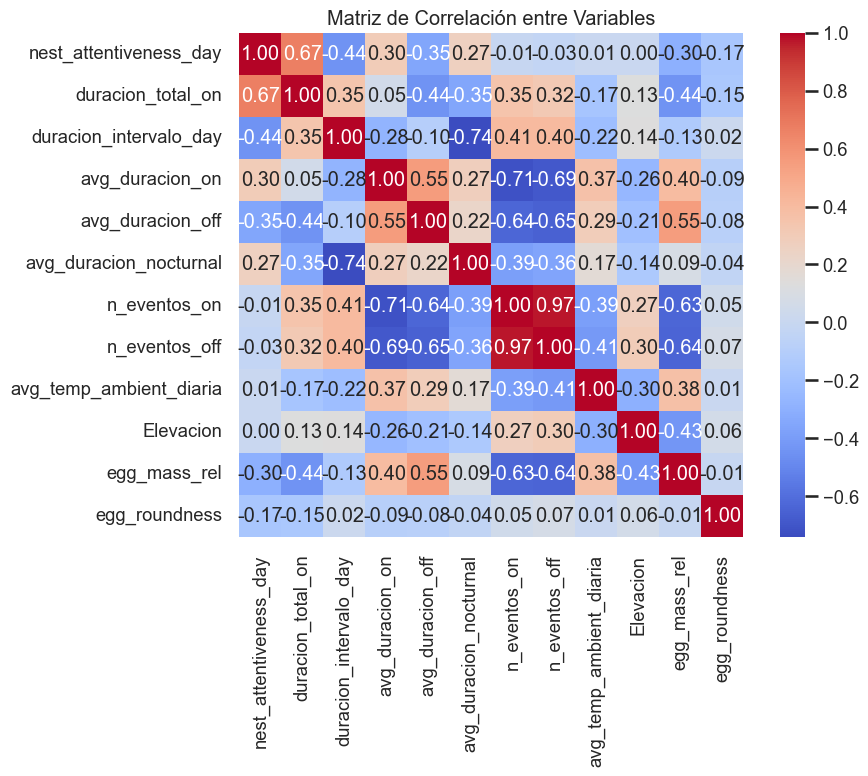

In [354]:
columnas_interes = [
    'nest_attentiveness_day', 'duracion_total_on', 'duracion_intervalo_day', 'avg_duracion_on',
    'avg_duracion_off', 'avg_duracion_nocturnal', 'n_eventos_on', 'n_eventos_off',
    'avg_temp_ambient_diaria', 'Elevacion', 'egg_mass_rel', 'egg_roundness'
]

TANGARA_ANALYTICS_READY = (
    not resumen_copy.empty
    and 'sp' in resumen_copy.columns
    and resumen_copy['sp'].notna().any()
)

if not TANGARA_ANALYTICS_READY:
    df_corr = pd.DataFrame(columns=columnas_interes)
    corr_matrix = pd.DataFrame()
    print("Skipping optional Tangara correlation heatmap because resumen_copy is empty.")
else:
    df_corr = resumen_copy[columnas_interes].dropna()
    corr_matrix = df_corr.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
    plt.title('Matriz de Correlación entre Variables')
    plt.tight_layout()
    plt.show()

In [355]:
estadisticas_altura = resumen_copy.groupby('sp')['nest_attentiveness_day'].agg(
    avg_attentiveness='mean',
    SD_attentiveness='std',
    N='count'
).reset_index()

print(estadisticas_altura)

                       sp  avg_attentiveness  SD_attentiveness    N
0  Myrmotherula hauxwelli           0.563325          0.196563   17
1       Tangara schrankii           0.619521          0.113470  164
2        Turdus hauxwelli           0.709523          0.111184   39


In [356]:
estadisticas_altura = resumen_copy.groupby('sp')['Elevacion'].agg(
    AVG_Elevation='mean',
    SD_Elevation='std',
    N='count'
).reset_index()

print(estadisticas_altura)

                       sp  AVG_Elevation  SD_Elevation    N
0  Myrmotherula hauxwelli     395.764706      9.430863   17
1       Tangara schrankii     504.408759    202.080377  137
2        Turdus hauxwelli     858.687500    420.168510   32


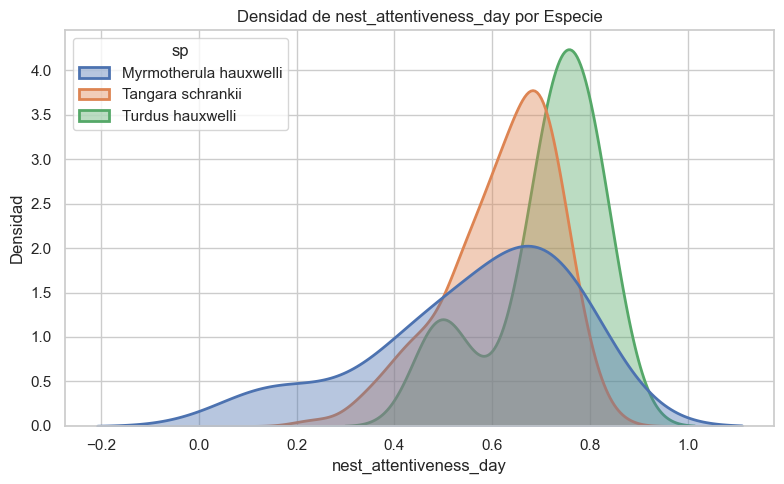

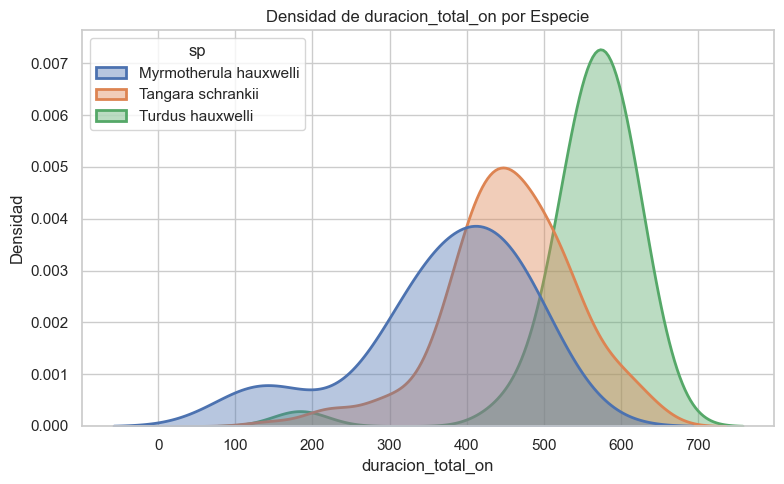

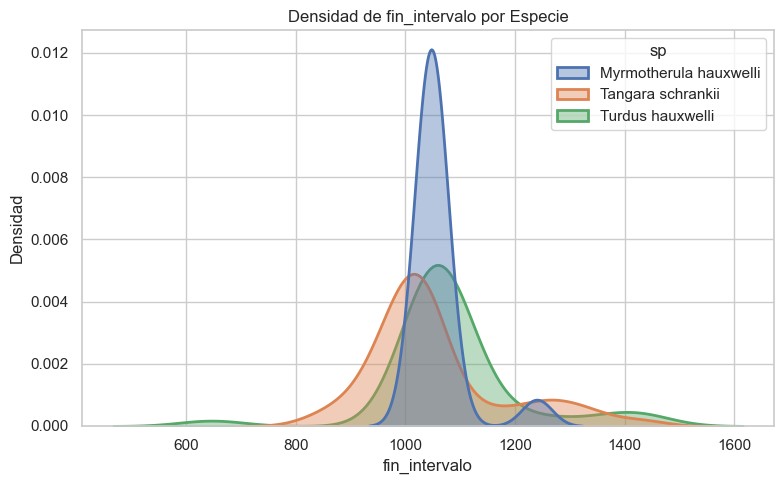

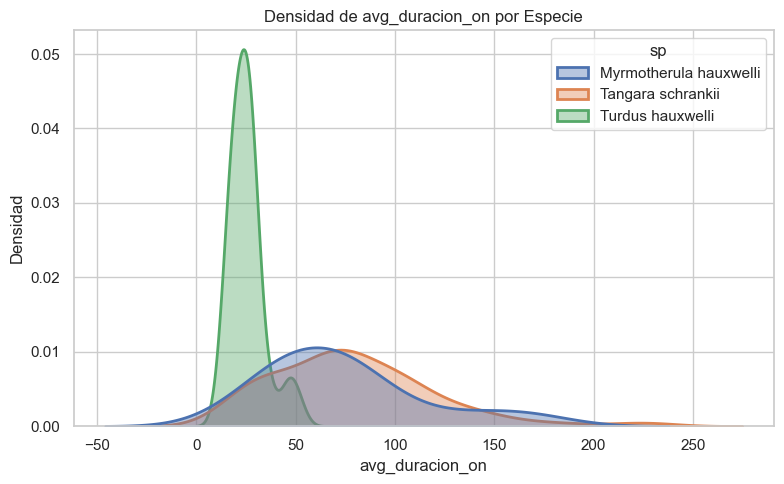

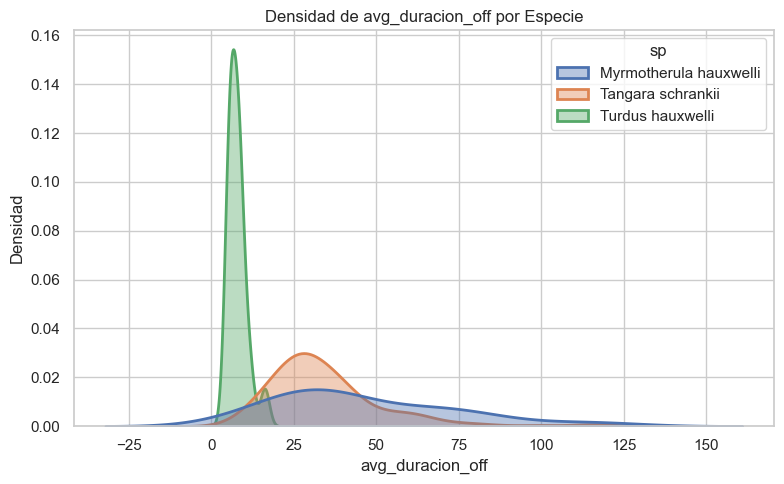

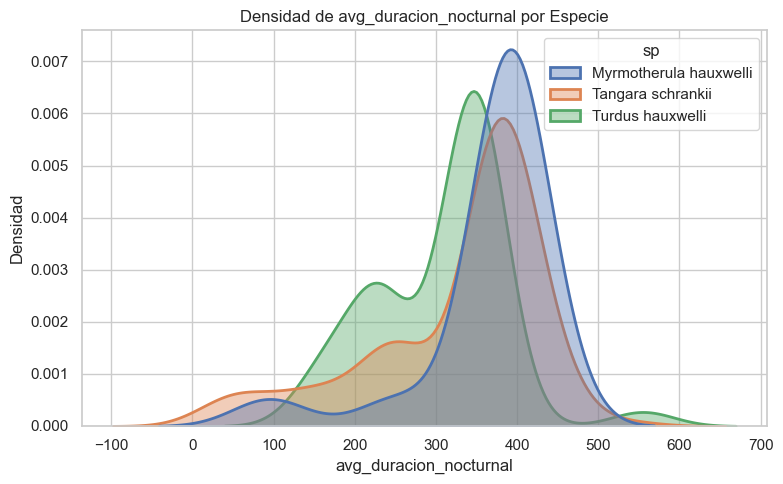

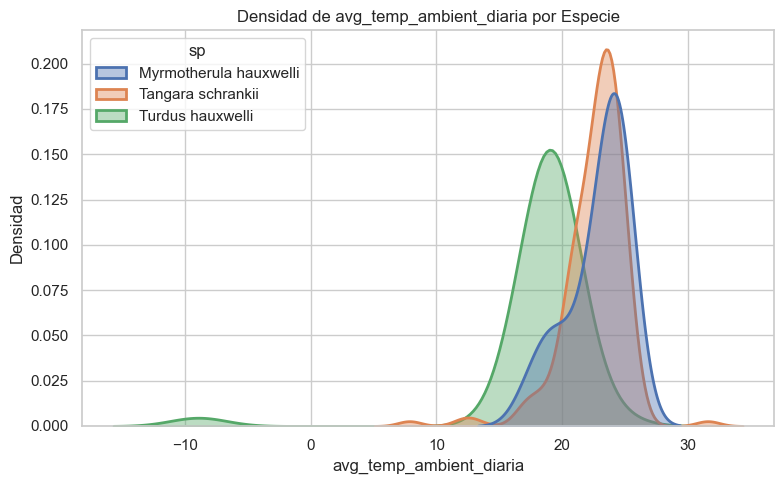

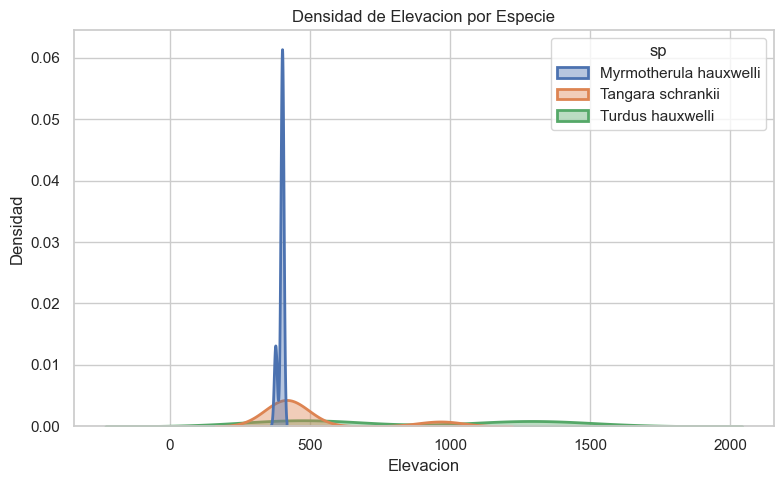

C:\Users\jorge\AppData\Local\Temp\ipykernel_6812\3029901966.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


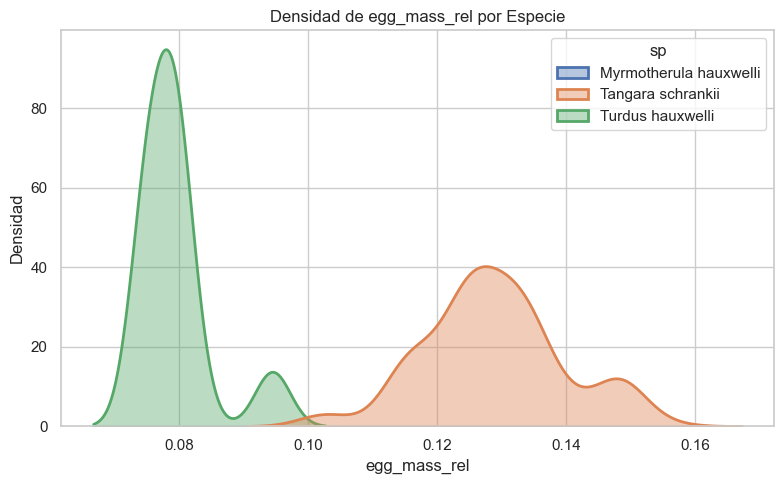

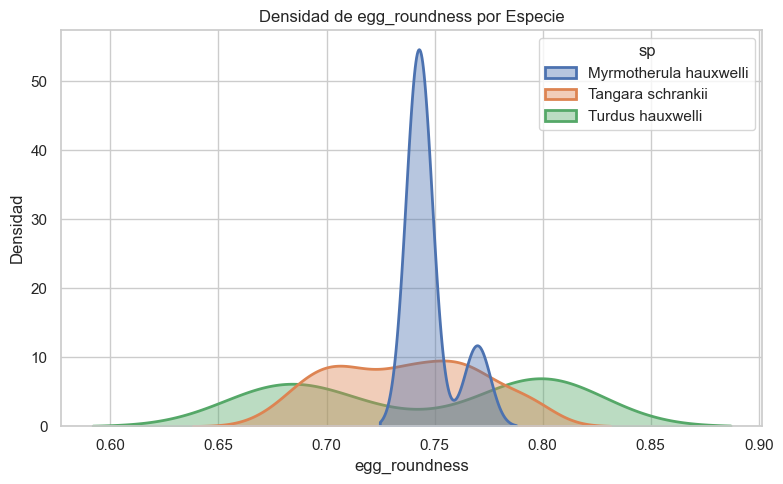

In [357]:
variables = [
    'nest_attentiveness_day', 'duracion_total_on', 'fin_intervalo', 'avg_duracion_on',
    'avg_duracion_off', 'avg_duracion_nocturnal', 'avg_temp_ambient_diaria',
    'Elevacion', 'egg_mass_rel', 'egg_roundness'
]

sns.set(style='whitegrid')

if not TANGARA_ANALYTICS_READY:
    print("Skipping optional Tangara KDE plots because resumen_copy is empty.")
else:
    for var in variables:
        plt.figure(figsize=(8, 5))
        sns.kdeplot(
            data=resumen_copy,
            x=var,
            hue='sp',
            fill=True,
            common_norm=False,
            alpha=0.4,
            linewidth=2
        )
        plt.title(f'Densidad de {var} por Especie')
        plt.xlabel(var)
        plt.ylabel('Densidad')
        plt.tight_layout()
        plt.show()

In [358]:
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [359]:
columnas_a_revisar = ['nest_attentiveness_day', 'duracion_total_on', 'avg_duracion_on', 'avg_duracion_off', 'avg_duracion_nocturnal', 'avg_temp_ambient_diaria', 'Elevacion', 'egg_mass_rel', 'egg_roundness']

# Filtrar filas con al menos un NaN en las columnas especificadas
nas_en_columnas = resumen_copy[resumen_copy[columnas_a_revisar].isna().any(axis=1)]

# Mostrar las filas con el ID correspondiente
resultado = nas_en_columnas[['nido_id'] + columnas_a_revisar]
print(resultado)

           nido_id  nest_attentiveness_day  duracion_total_on  \
19         T1b_GVC                0.597101                412   
32   P10(a)_JMGP12                0.655098                604   
33   P10(a)_JMGP12                0.655902                589   
34   P10(a)_JMGP12                0.681614                456   
58      P17a_MAL10                0.636656                396   
59      P17a_MAL10                0.678275                409   
60      P17a_MAL10                0.677326                466   
78       P29_RVA11                0.523077                442   
79       P29_RVA11                0.439201                484   
97       P34_CAB10                0.553594                439   
118     P53b_JAG10                0.781295                543   
119     P53b_JAG10                0.775964                523   
133        T1a_jag                0.348123                306   
134        T1a_jag                0.392670                225   
135        T1a_jag       

In [360]:
_columnas_pca_full = [
    'nest_attentiveness_day', 'duracion_total_on', 'avg_duracion_on',
    'avg_duracion_off', 'avg_duracion_nocturnal', 'avg_temp_ambient_diaria',
    'Elevacion', 'egg_mass_rel', 'egg_roundness'
]

# Drop variables that are entirely (or almost entirely) missing in the current
# Tangara mapping so the downstream PCA / KMeans / F-test step does not collapse
# to an empty dataframe. The Base_tangara morphometric / elevation table only
# covers a subset of nests; if those columns have no usable values we simply
# fall back to the behavioural columns that are always present.
_min_non_na = 10
if 'resumen_copy' in globals() and not resumen_copy.empty:
    columnas_pca = [
        c for c in _columnas_pca_full
        if c in resumen_copy.columns and resumen_copy[c].notna().sum() >= _min_non_na
    ]
    if not columnas_pca:
        columnas_pca = list(_columnas_pca_full)
else:
    columnas_pca = list(_columnas_pca_full)

print(f"PCA variables ({len(columnas_pca)}):", columnas_pca)


PCA variables (9): ['nest_attentiveness_day', 'duracion_total_on', 'avg_duracion_on', 'avg_duracion_off', 'avg_duracion_nocturnal', 'avg_temp_ambient_diaria', 'Elevacion', 'egg_mass_rel', 'egg_roundness']


In [361]:
if not TANGARA_ANALYTICS_READY:
    df_pca = pd.DataFrame(columns=columnas_pca)
    X_scaled = np.empty((0, len(columnas_pca)))
    print("Skipping optional PCA scaling because resumen_copy is empty.")
else:
    df_pca = resumen_copy[columnas_pca].dropna()
    if df_pca.empty:
        X_scaled = np.empty((0, len(columnas_pca)))
        print("Skipping optional PCA scaling because there are no complete Tangara rows.")
    else:
        X_scaled = StandardScaler().fit_transform(df_pca)

In [362]:
if X_scaled.size == 0:
    pca = None
    X_pca = np.empty((0, 0))
    print("Skipping optional PCA fit because X_scaled is empty.")
else:
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)

In [363]:
if pca is None:
    var_exp = np.array([])
    var_cumsum = np.array([])
else:
    var_exp = pca.explained_variance_ratio_
    var_cumsum = np.cumsum(var_exp)

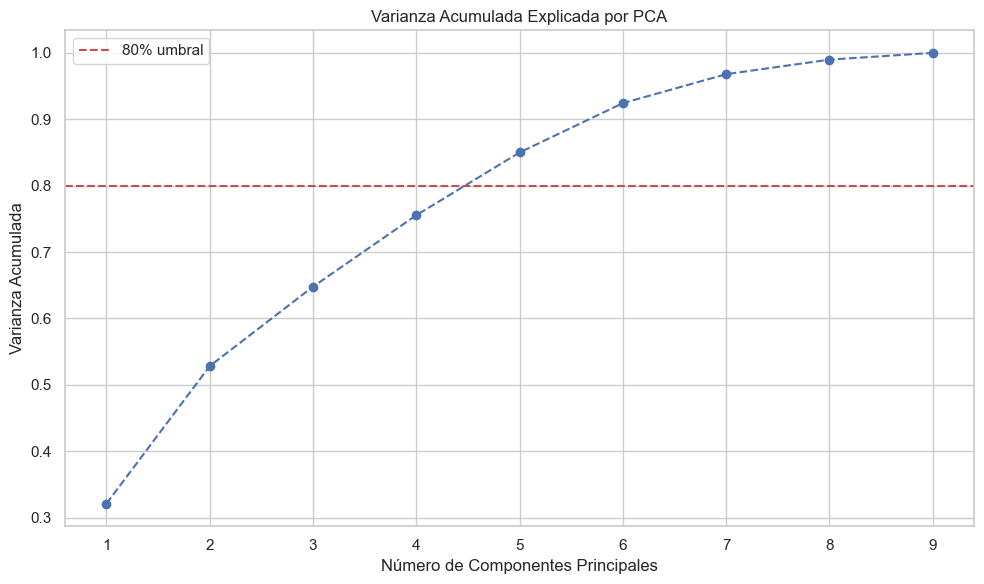

In [364]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(var_exp) + 1), var_cumsum, marker='o', linestyle='--')
plt.title('Varianza Acumulada Explicada por PCA')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada')
plt.grid(True)
plt.axhline(0.80, color='r', linestyle='--', label='80% umbral')
plt.legend()
plt.tight_layout()
plt.show()

In [365]:
if not TANGARA_ANALYTICS_READY:
    df_pca = pd.DataFrame(columns=columnas_pca + ['sp'])
    print("Skipping optional PCA species dataframe because resumen_copy is empty.")
else:
    df_pca = resumen_copy.dropna(subset=columnas_pca + ['sp']).copy()

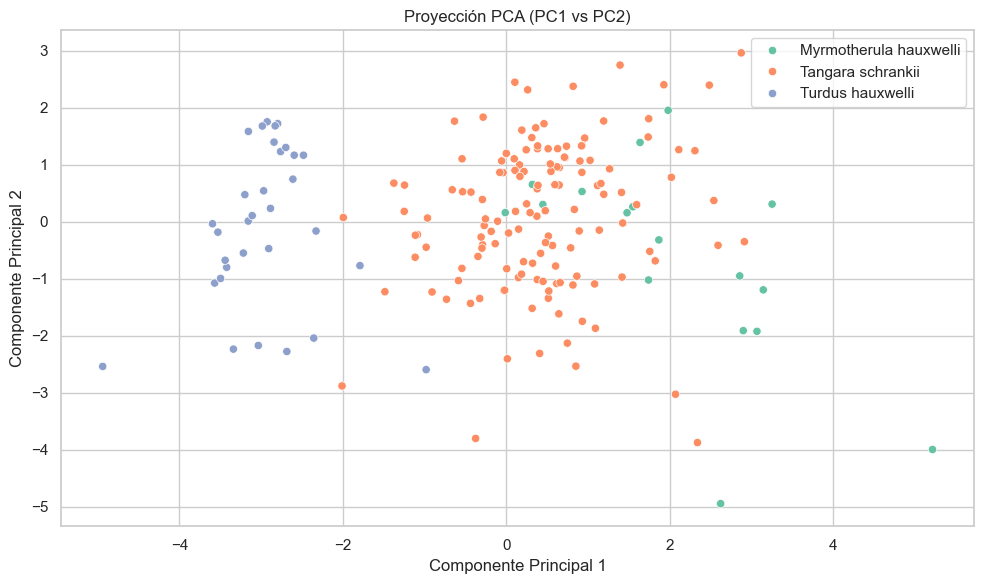

In [366]:
if df_pca.empty or X_scaled.size == 0:
    df_pca_resultado = pd.DataFrame(columns=['PC1', 'PC2', 'PC3', 'PC4', 'sp'])
    print("Skipping optional PCA scatter projection because there are no complete Tangara rows.")
else:
    pca = PCA(n_components=4)
    X_pca = pca.fit_transform(X_scaled)
    df_pca_resultado = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3', 'PC4'])
    df_pca_resultado['sp'] = df_pca['sp'].values

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_pca_resultado, x='PC1', y='PC2', hue='sp', palette='Set2')
    plt.title('Proyección PCA (PC1 vs PC2)')
    plt.xlabel('Componente Principal 1')
    plt.ylabel('Componente Principal 2')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [367]:
if X_scaled.size == 0:
    pca_final = None
    X_pca_final = np.empty((0, 0))
    loadings = pd.DataFrame()
    print("Skipping optional final PCA loadings because X_scaled is empty.")
else:
    pca_final = PCA(n_components=4)
    X_pca_final = pca_final.fit_transform(X_scaled)
    loadings = pd.DataFrame(
        pca_final.components_.T,
        columns=[f'PC{i+1}' for i in range(pca_final.n_components_)],
        index=columnas_pca
    )

In [368]:
features = columnas_pca

if pca is None:
    loadings = pd.DataFrame(columns=['PC1', 'PC2', 'PC3', 'PC4'], index=features)
    print("Skipping optional PCA loadings table because PCA was not fitted.")
else:
    loadings = pd.DataFrame(
        pca.components_[:4].T,
        columns=['PC1', 'PC2', 'PC3', 'PC4'],
        index=features
    )
    print(loadings)

                              PC1       PC2       PC3       PC4
nest_attentiveness_day  -0.215151  0.636244  0.170232  0.108188
duracion_total_on       -0.380802  0.430083 -0.342956  0.122040
avg_duracion_on          0.331213  0.460929 -0.043686  0.024501
avg_duracion_off         0.474496 -0.013165 -0.039403 -0.266722
avg_duracion_nocturnal   0.219307  0.238042  0.789510 -0.136476
avg_temp_ambient_diaria  0.333241  0.199605 -0.090819  0.356141
Elevacion               -0.299927 -0.175650  0.264173 -0.255473
egg_mass_rel             0.474077 -0.036752 -0.261916  0.049906
egg_roundness           -0.001013 -0.262456  0.282807  0.829724


In [369]:
if pca is None:
    print("Skipping optional PCA explained-variance report because PCA was not fitted.")
else:
    for i, var in enumerate(pca.explained_variance_ratio_):
        print(f"PC{i+1}: {var:.2%} d varianze")

PC1: 32.10% d varianze
PC2: 20.72% d varianze
PC3: 11.96% d varianze
PC4: 10.77% d varianze


In [370]:
range_n_clusters = range(2, 11)
n_iter = 30 # número de random_state diferentes para promediar
silhouette_avg = []
inertia_avg = []

In [371]:
if X_pca.size == 0:
    range_n_clusters = []
    n_iter = 0
    silhouette_avg = []
    inertia_avg = []
    print("Skipping optional KMeans model selection because PCA coordinates are empty.")
else:
    range_n_clusters = range(2, 11)
    n_iter = 30
    silhouette_avg = []
    inertia_avg = []
    for k in range_n_clusters:
        sil_runs, ine_runs = [], []
        for rs in range(n_iter):
            km = KMeans(n_clusters=k, random_state=rs, n_init=10).fit(X_pca)
            sil_runs.append(silhouette_score(X_pca, km.labels_))
            ine_runs.append(km.inertia_)
        silhouette_avg.append(float(np.mean(sil_runs)))
        inertia_avg.append(float(np.mean(ine_runs)))
    print(f"KMeans model selection over k=2..10 with {n_iter} random seeds completed.")


KMeans model selection over k=2..10 with 30 random seeds completed.


Text(0.5, 1.0, 'Método del Codo')

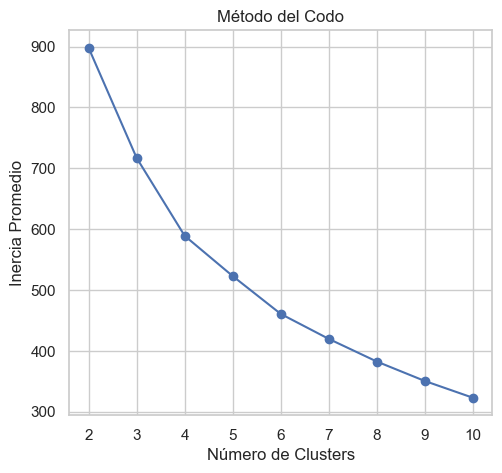

In [372]:
# Plot resultados
plt.figure(figsize=(12, 5))

# Elbow (Inertia)
plt.subplot(1, 2, 1)
plt.plot(range_n_clusters, inertia_avg, marker='o')
plt.xlabel("Número de Clusters")
plt.ylabel("Inercia Promedio")
plt.title("Método del Codo")

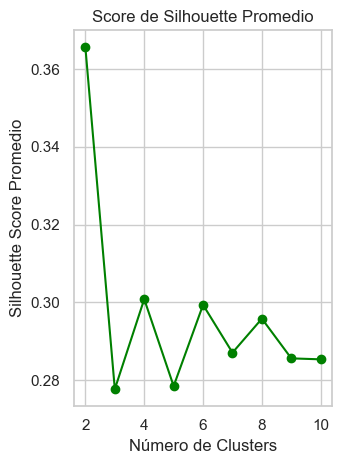

In [373]:
plt.subplot(1, 2, 2)
plt.plot(range_n_clusters, silhouette_avg, marker='o', color='green')
plt.xlabel("Número de Clusters")
plt.ylabel("Silhouette Score Promedio")
plt.title("Score de Silhouette Promedio")

plt.tight_layout()
plt.show()

In [374]:
if not silhouette_avg:
    best_k = None
    print("Skipping optional KMeans selection because silhouette scores are unavailable.")
else:
    best_k = range_n_clusters[np.argmax(silhouette_avg)]
    print(f"✅ Mejor número de clusters (basado en silhouette): {best_k}")

✅ Mejor número de clusters (basado en silhouette): 2


In [375]:
if best_k is None or X_pca.size == 0:
    kmeans_final = None
    labels_final = np.array([], dtype=int)
    df_pca_resultado = pd.DataFrame(columns=['PC1', 'PC2', 'PC3', 'PC4', 'cluster', 'sp'])
    print("Skipping optional final KMeans fit because PCA coordinates are empty.")
else:
    kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=50)
    labels_final = kmeans_final.fit_predict(X_pca)

    df_pca_resultado = pd.DataFrame(
        X_pca[:, :4],
        columns=['PC1', 'PC2', 'PC3', 'PC4'],
        index=df_pca.index,
    )
    df_pca_resultado['cluster'] = labels_final
    # Pull the species column from the surviving (dropna'd) PCA rows so the
    # length matches X_pca even when the 9-column PCA drops rows lacking
    # morphometric/elevation values.
    df_pca_resultado['sp'] = resumen_copy.loc[df_pca.index, 'sp'].values

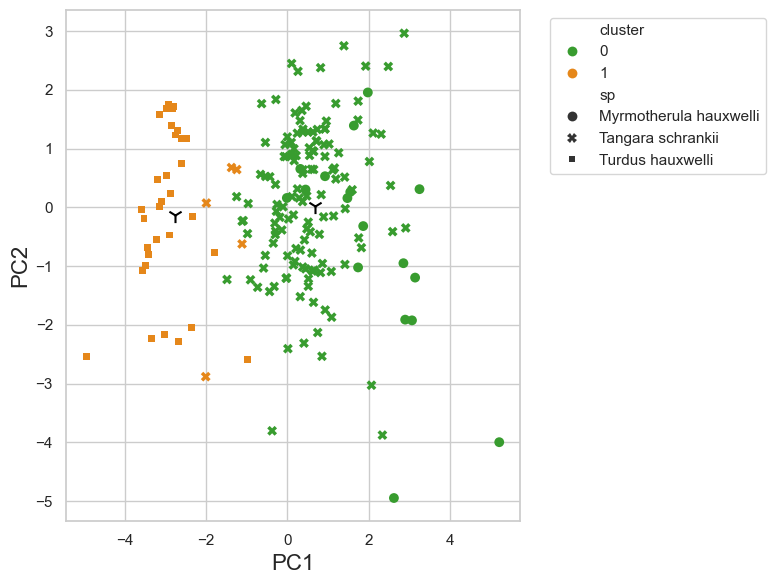

In [376]:
# Build a palette covering whatever number of clusters silhouette selected.
_base_cluster_palette = {0: '#389C2F', 1: '#E5871A'}
if kmeans_final is not None and labels_final.size:
    _n_clu = int(np.unique(labels_final).size)
    if _n_clu > len(_base_cluster_palette):
        _extra = sns.color_palette('tab10', n_colors=max(_n_clu, 2))
        cluster_palette = {i: _base_cluster_palette.get(i, _extra[i]) for i in range(_n_clu)}
    else:
        cluster_palette = dict(_base_cluster_palette)
else:
    cluster_palette = dict(_base_cluster_palette)

if df_pca_resultado.empty or kmeans_final is None:
    print("Skipping optional Tangara cluster plot because clustered PCA data are unavailable.")
else:
    plt.figure(figsize=(8, 6))
    ax = sns.scatterplot(
        data=df_pca_resultado,
        x='PC1', y='PC2',
        hue='cluster',
        style='sp',
        palette=cluster_palette,
        s=50,
        edgecolor='none',
        linewidth=0
    )

    centroids = kmeans_final.cluster_centers_
    ax.scatter(
        centroids[:, 0], centroids[:, 1],
        c='black', marker='1', s=120,
        label='_nolegend_'
    )

    plt.xlabel('PC1', fontsize=16)
    plt.ylabel('PC2', fontsize=16)
    plt.title('')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(TANGARA_GRAPH_DIR / 'kmeans_tangara.png', dpi=300, transparent=True, bbox_inches='tight')
    plt.show()


In [377]:
if len(labels_final) == 0:
    resumen_copy['cluster'] = pd.Series(dtype=float)
    df_cluster_analisis = pd.DataFrame(columns=['cluster', 'sp'])
    print("Skipping optional cluster assignment because no labels were produced.")
else:
    # Index-aligned assignment so rows excluded from PCA (NaN morphometrics)
    # simply get NaN cluster labels instead of triggering a length error.
    resumen_copy['cluster'] = pd.Series(labels_final, index=df_pca.index)
    df_cluster_analisis = resumen_copy[['cluster', 'sp']].dropna()

In [378]:
if 'tabla' not in globals() or tabla.empty:
    proporcion = pd.DataFrame()
    print("Skipping optional cluster proportion table because tabla is unavailable.")
else:
    proporcion = tabla.div(tabla.sum(axis=1), axis=0)
    print(proporcion.round(2))

Skipping optional cluster proportion table because tabla is unavailable.


In [379]:
from scipy.stats import chi2_contingency

# Build the contingency table (clusters x species) directly from the assigned
# cluster labels and canonical species column. This replaces the previous
# skip-guard that depended on an externally defined `cont` variable that was
# never built earlier in the notebook.
_species_order = ['Myrmotherula hauxwelli', 'Tangara schrankii', 'Turdus hauxwelli']
if 'cluster' not in resumen_copy.columns or 'sp' not in resumen_copy.columns:
    print("Skipping standardised residuals: cluster or sp column missing.")
else:
    cont = (
        pd.crosstab(resumen_copy['cluster'], resumen_copy['sp'])
        .reindex(columns=_species_order, fill_value=0)
    )

    print("=== Contingency table (cluster x species) ===")
    print(cont)

    chi2, p, dof, expected = chi2_contingency(cont.values)
    expected = pd.DataFrame(expected, index=cont.index, columns=cont.columns)
    std_resid = (cont - expected) / np.sqrt(expected)

    print("\n=== Standardised residuals (wide) ===")
    print(std_resid.round(2))

    resid_long = (
        std_resid.stack()
        .rename('std_resid')
        .reset_index()
        .rename(columns={'cluster': 'Cluster', 'sp': 'Especie'})
    )
    resid_long = (
        resid_long.assign(_abs=resid_long['std_resid'].abs())
        .sort_values('_abs', ascending=False)
        .drop(columns='_abs')
    )

    print("\n=== Standardised residuals (long, sorted by |residual|) ===")
    print(resid_long.to_string(index=False))


=== Contingency table (cluster x species) ===
sp       Myrmotherula hauxwelli  Tangara schrankii  Turdus hauxwelli
cluster                                                             
0.0                          17                132                 0
1.0                           0                  5                32

=== Standardised residuals (wide) ===
sp       Myrmotherula hauxwelli  Tangara schrankii  Turdus hauxwelli
cluster                                                             
0.0                        0.92               2.12             -5.06
1.0                       -1.84              -4.26             10.16

=== Standardised residuals (long, sorted by |residual|) ===
 Cluster                Especie  std_resid
     1.0       Turdus hauxwelli  10.160239
     0.0       Turdus hauxwelli  -5.063043
     1.0      Tangara schrankii  -4.262632
     0.0      Tangara schrankii   2.124152
     1.0 Myrmotherula hauxwelli  -1.838945
     0.0 Myrmotherula hauxwelli   0.916382


In [380]:
resumen_copy = resumen_copy.reset_index(drop=True)
df_pca_resultado = df_pca_resultado.reset_index(drop=True)

resumen_copy['cluster'] = df_pca_resultado['cluster']

In [381]:
if 'cluster' not in resumen_copy.columns or resumen_copy.empty:
    resumen_clusters = pd.DataFrame()
    print("Skipping optional cluster summary because cluster assignments are unavailable.")
else:
    resumen_clusters = resumen_copy.groupby('cluster')[columnas_pca].mean().round(2).T
    print(resumen_clusters)

cluster                     0.0     1.0
nest_attentiveness_day     0.61    0.64
duracion_total_on        444.49  475.32
avg_duracion_on           76.87   76.12
avg_duracion_off          35.18   33.25
avg_duracion_nocturnal   336.36  296.31
avg_temp_ambient_diaria   22.75   21.50
Elevacion                439.00  676.38
egg_mass_rel               0.13    0.12
egg_roundness              0.74    0.73


In [382]:
if 'cluster' not in resumen_copy.columns or resumen_copy.empty:
    resumen_detallado = pd.DataFrame()
    print("Skipping optional detailed cluster summary because cluster assignments are unavailable.")
else:
    resumen_media = resumen_copy.groupby('cluster')[columnas_pca].mean().round(2).T
    resumen_std = resumen_copy.groupby('cluster')[columnas_pca].std().round(2).T

    resumen_detallado = resumen_media.copy()
    for c in resumen_media.columns:
        resumen_detallado[c] = resumen_media[c].astype(str) + ' ± ' + resumen_std[c].astype(str)

    resumen_detallado.columns = [f'Cluster {c}' for c in resumen_detallado.columns]
    print(resumen_detallado)

                            Cluster 0.0      Cluster 1.0
nest_attentiveness_day      0.61 ± 0.13      0.64 ± 0.11
duracion_total_on        444.49 ± 95.94   475.32 ± 70.18
avg_duracion_on           76.87 ± 42.25    76.12 ± 37.08
avg_duracion_off          35.18 ± 19.74    33.25 ± 17.49
avg_duracion_nocturnal   336.36 ± 98.86  296.31 ± 122.75
avg_temp_ambient_diaria    22.75 ± 2.32      21.5 ± 3.35
Elevacion                439.0 ± 114.05  676.38 ± 283.33
egg_mass_rel                0.13 ± 0.01      0.12 ± 0.02
egg_roundness               0.74 ± 0.03      0.73 ± 0.03


In [383]:
if loadings.empty or 'cluster' not in resumen_copy.columns or resumen_copy.empty:
    top_vars = set()
    print("Skipping optional variable ranking because PCA loadings or cluster assignments are unavailable.")
else:
    ranking_pca = loadings.abs().sum(axis=1).sort_values(ascending=False)
    print('=== Ranking de importancia según PCA ===')
    print(ranking_pca)

    from sklearn.feature_selection import f_classif

    _f_input = resumen_copy[columnas_pca + ['cluster']].dropna()
    if _f_input.empty or _f_input['cluster'].nunique() < 2:
        ranking_anova = pd.Series(dtype=float)
        print("Skipping optional F-test because no complete rows are available across PCA columns and clusters.")
    else:
        X_sel = _f_input[columnas_pca].values
        y_sel = _f_input['cluster'].values
        f_vals, p_vals = f_classif(X_sel, y_sel)
        ranking_anova = pd.Series(f_vals, index=columnas_pca).sort_values(ascending=False)
        print('\n=== Ranking de importancia según F-test entre clusters ===')
        print(ranking_anova)

    top_pca = list(ranking_pca.head(6).index)
    top_an = list(ranking_anova.head(6).index) if not ranking_anova.empty else []
    top_vars = set(top_pca) | set(top_an)
    print('\nVariables seleccionadas para análisis detallado:')
    print(top_vars)


=== Ranking de importancia según PCA ===
avg_duracion_nocturnal     1.383335
egg_roundness              1.376000
duracion_total_on          1.275880
nest_attentiveness_day     1.129814
Elevacion                  0.995224
avg_temp_ambient_diaria    0.979805
avg_duracion_on            0.860330
egg_mass_rel               0.822652
avg_duracion_off           0.793785
dtype: float64

=== Ranking de importancia según F-test entre clusters ===
Elevacion                  55.484101
egg_mass_rel               45.787666
avg_temp_ambient_diaria    10.004483
avg_duracion_nocturnal      5.829738
duracion_total_on           3.189234
egg_roundness               1.638186
nest_attentiveness_day      1.172801
avg_duracion_off            0.664413
avg_duracion_on             0.259885
dtype: float64

Variables seleccionadas para análisis detallado:
{'avg_temp_ambient_diaria', 'egg_roundness', 'egg_mass_rel', 'avg_duracion_nocturnal', 'nest_attentiveness_day', 'duracion_total_on', 'Elevacion'}


In [384]:
import scikit_posthocs as sp
from scipy.stats import kruskal

SPECIES_ORDER = ['Myrmotherula hauxwelli', 'Tangara schrankii', 'Turdus hauxwelli']
SPECIES_PALETTE = {
    'Myrmotherula hauxwelli': '#21134D',
    'Tangara schrankii': '#389C2F',
    'Turdus hauxwelli': '#E5871A'
}

def run_safe_kruskal_dunn(df, value_col, group_col='sp'):
    if df.empty or group_col not in df.columns or value_col not in df.columns:
        print(f"Skipping {value_col} comparison because required Tangara columns are unavailable.")
        return None

    groups = [
        df.loc[df[group_col] == especie, value_col].dropna()
        for especie in df[group_col].dropna().unique()
    ]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) < 2:
        print(f"Skipping {value_col} comparison because fewer than two species have data.")
        return None

    stat, p = kruskal(*groups)
    print(f"Kruskal-Wallis H = {stat:.3f}, p = {p:.3e}")

    dunn = sp.posthoc_dunn(df, val_col=value_col, group_col=group_col, p_adjust='holm')
    print(dunn)
    return dunn

def plot_species_violin(df, value_col, ylabel, filename):
    if df.empty or 'sp' not in df.columns or value_col not in df.columns:
        print(f"Skipping {value_col} violin plot because required Tangara columns are unavailable.")
        return

    sns.set(style='whitegrid', context='talk', font_scale=0.8)
    plt.figure(figsize=(4, 3), dpi=300)

    sns.violinplot(
        data=df,
        x='sp',
        y=value_col,
        order=SPECIES_ORDER,
        palette=SPECIES_PALETTE,
        inner='box',
        cut=0,
        alpha=0.5,
        linewidth=0.8
    )

    sns.stripplot(
        data=df,
        x='sp',
        y=value_col,
        order=SPECIES_ORDER,
        color='0.3',
        alpha=0.3,
        jitter=0.25,
        size=2
    )

    plt.ylabel(ylabel, fontsize=14)
    plt.xlabel('')
    plt.xticks(
        ticks=[0, 1, 2],
        labels=['I. hauxwelli', 'T. schrankii', 'T. hauxwelli'],
        fontsize=9
    )

    sns.despine()
    plt.tight_layout()
    plt.savefig(TANGARA_GRAPH_DIR / filename, dpi=300, transparent=True, bbox_inches='tight')
    plt.show()

In [385]:
run_safe_kruskal_dunn(resumen_copy, 'nest_attentiveness_day')

Kruskal-Wallis H = 23.885, p = 6.507e-06
                        Myrmotherula hauxwelli  Tangara schrankii  \
Myrmotherula hauxwelli                1.000000           0.591703   
Tangara schrankii                     0.591703           1.000000   
Turdus hauxwelli                      0.001466           0.000006   

                        Turdus hauxwelli  
Myrmotherula hauxwelli          0.001466  
Tangara schrankii               0.000006  
Turdus hauxwelli                1.000000  


,Myrmotherula hauxwelli,Tangara schrankii,Turdus hauxwelli
Myrmotherula hauxwelli,1.000000,0.591703,0.001466
Tangara schrankii,0.591703,1.000000,0.000006
Turdus hauxwelli,0.001466,0.000006,1.000000


C:\Users\jorge\AppData\Local\Temp\ipykernel_6812\2200060651.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


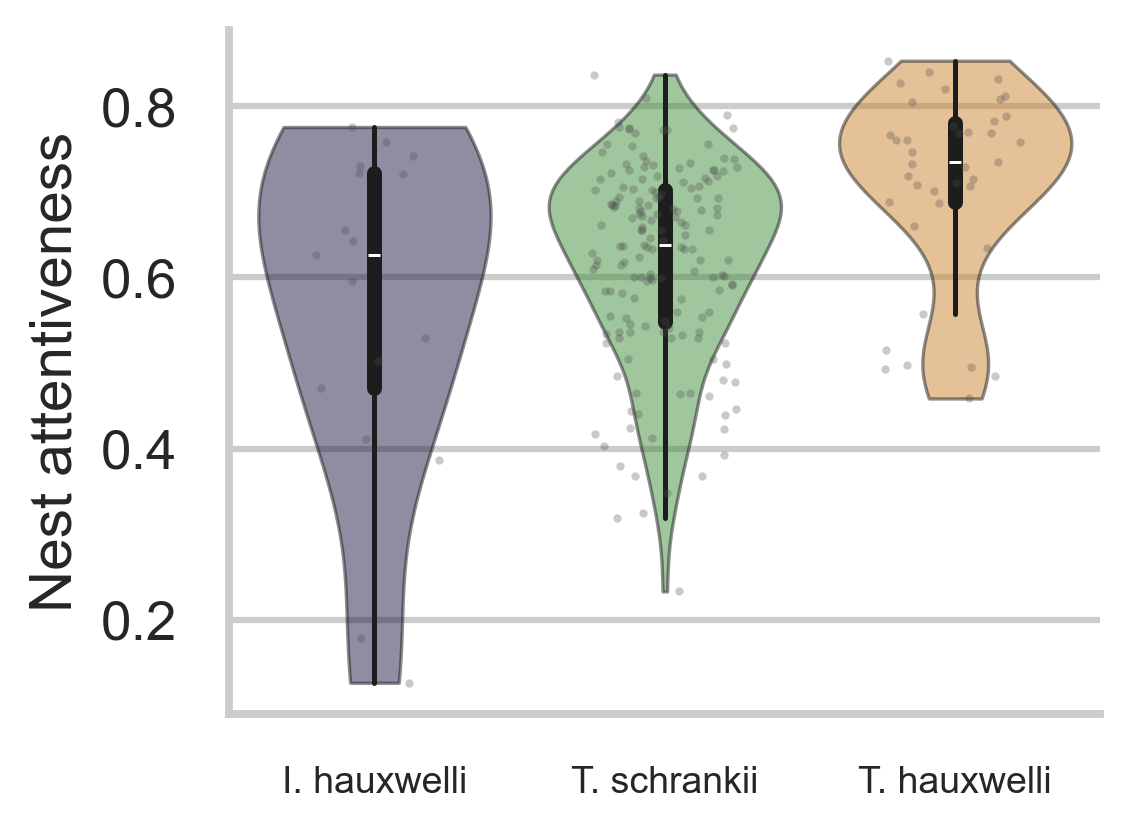

In [386]:
plot_species_violin(
    resumen_copy,
    value_col='nest_attentiveness_day',
    ylabel='Nest attentiveness',
    filename='attentiveness_3species.png'
)

C:\Users\jorge\AppData\Local\Temp\ipykernel_6812\2200060651.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


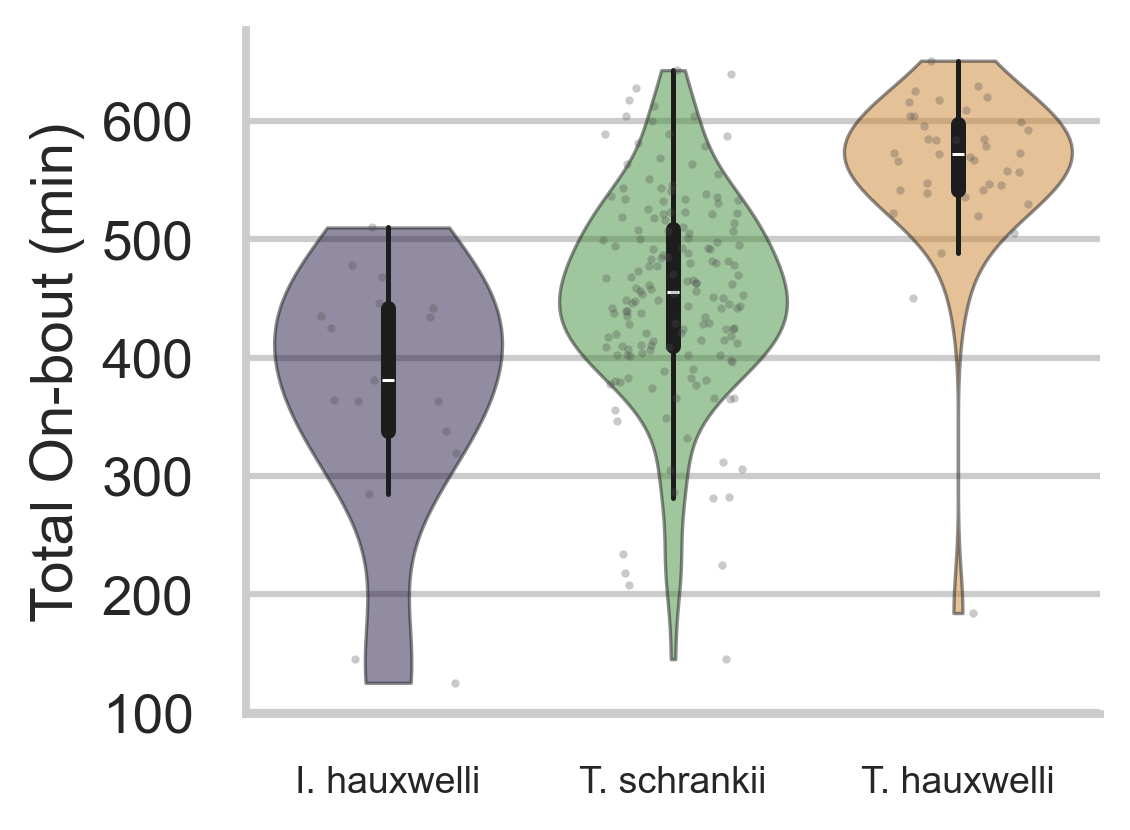

In [387]:
plot_species_violin(
    resumen_copy,
    value_col='duracion_total_on',
    ylabel='Total On-bout (min)',
    filename='totalOn_3species.png'
)

C:\Users\jorge\AppData\Local\Temp\ipykernel_6812\2200060651.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


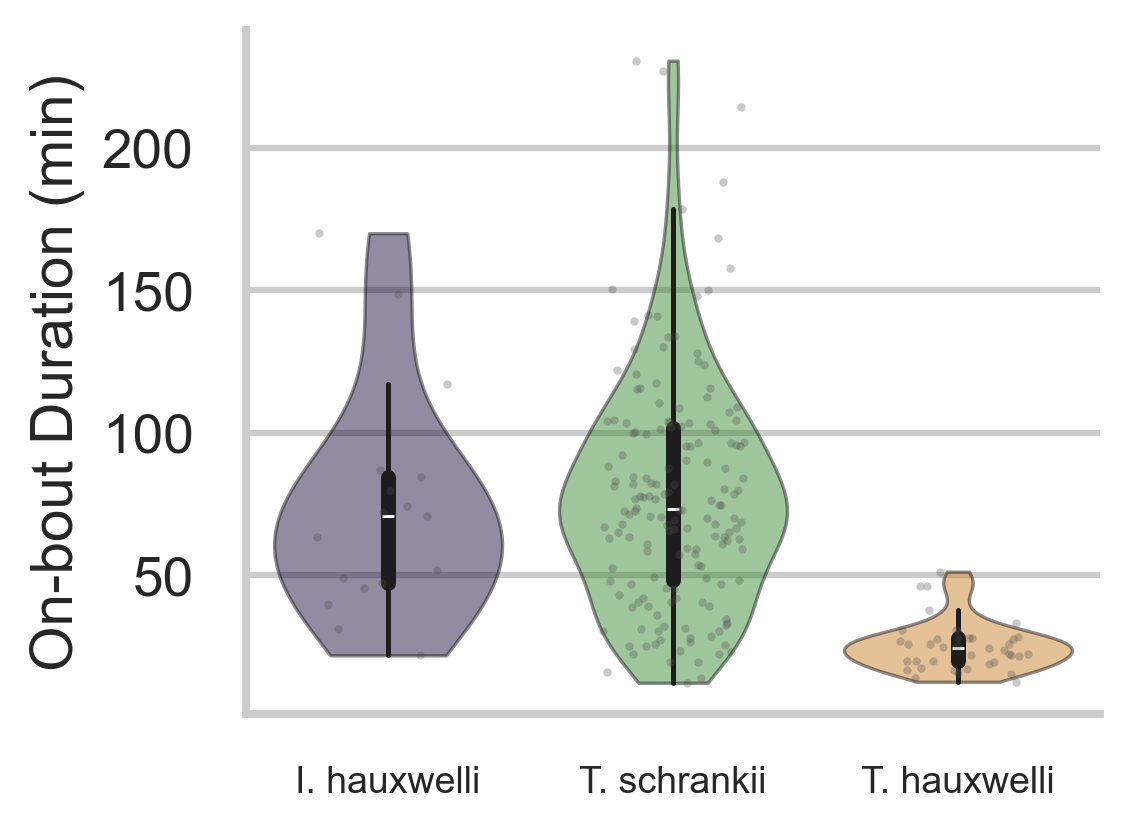

In [388]:
plot_species_violin(
    resumen_copy,
    value_col='avg_duracion_on',
    ylabel='On-bout Duration (min)',
    filename='On-Bout_3species.png'
)

In [389]:
run_safe_kruskal_dunn(resumen_copy, 'egg_mass_rel')

Kruskal-Wallis H = 110.512, p = 1.006e-24
                        Myrmotherula hauxwelli  Tangara schrankii  \
Myrmotherula hauxwelli            1.000000e+00       2.464941e-06   
Tangara schrankii                 2.464941e-06       1.000000e+00   
Turdus hauxwelli                  7.626019e-17       2.559400e-11   

                        Turdus hauxwelli  
Myrmotherula hauxwelli      7.626019e-17  
Tangara schrankii           2.559400e-11  
Turdus hauxwelli            1.000000e+00  


,Myrmotherula hauxwelli,Tangara schrankii,Turdus hauxwelli
Myrmotherula hauxwelli,1.000000e+00,2.464941e-06,7.626019e-17
Tangara schrankii,2.464941e-06,1.000000e+00,2.559400e-11
Turdus hauxwelli,7.626019e-17,2.559400e-11,1.000000e+00


In [390]:
run_safe_kruskal_dunn(resumen_copy, 'avg_duracion_off')

Kruskal-Wallis H = 95.719, p = 1.640e-21
                        Myrmotherula hauxwelli  Tangara schrankii  \
Myrmotherula hauxwelli            1.000000e+00       1.190441e-01   
Tangara schrankii                 1.190441e-01       1.000000e+00   
Turdus hauxwelli                  2.401410e-12       2.353691e-20   

                        Turdus hauxwelli  
Myrmotherula hauxwelli      2.401410e-12  
Tangara schrankii           2.353691e-20  
Turdus hauxwelli            1.000000e+00  


,Myrmotherula hauxwelli,Tangara schrankii,Turdus hauxwelli
Myrmotherula hauxwelli,1.000000e+00,1.190441e-01,2.401410e-12
Tangara schrankii,1.190441e-01,1.000000e+00,2.353691e-20
Turdus hauxwelli,2.401410e-12,2.353691e-20,1.000000e+00


C:\Users\jorge\AppData\Local\Temp\ipykernel_6812\2200060651.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


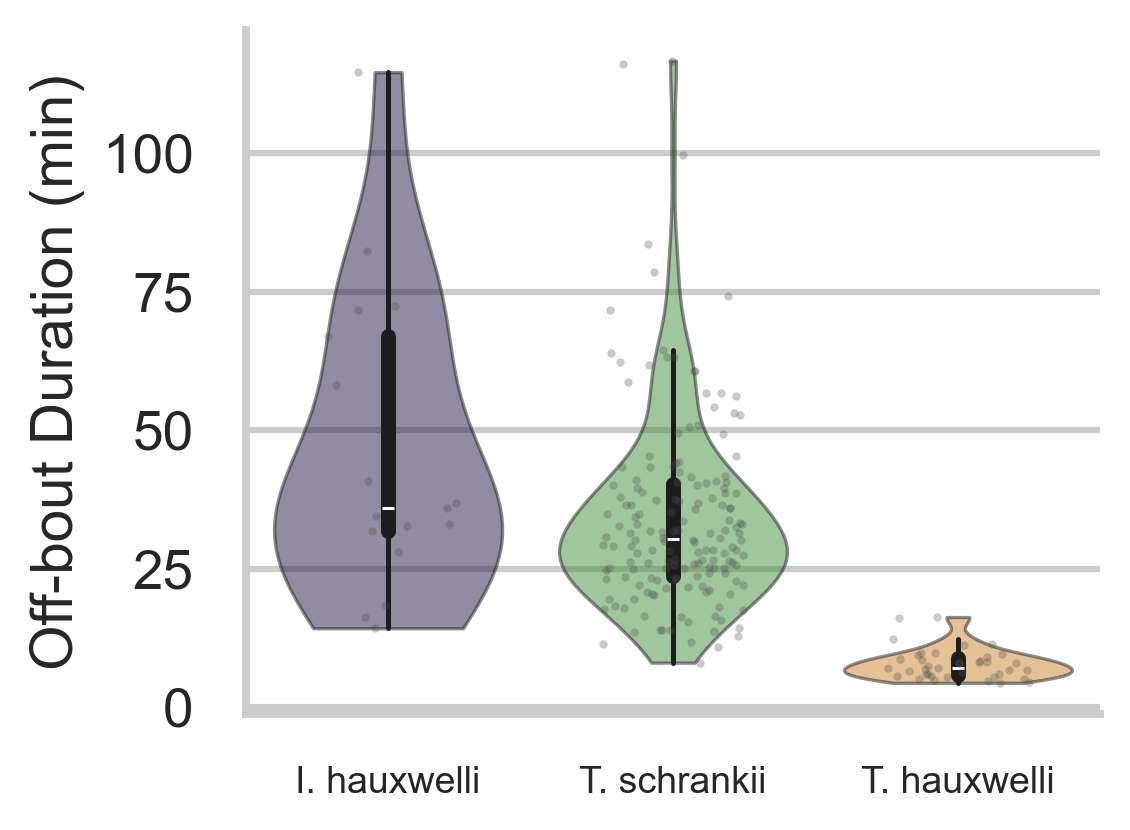

In [391]:
plot_species_violin(
    resumen_copy,
    value_col='avg_duracion_off',
    ylabel='Off-bout Duration (min)',
    filename='Off-Bout_3species.png'
)

In [392]:
run_safe_kruskal_dunn(resumen_copy, 'avg_duracion_nocturnal')

Kruskal-Wallis H = 23.726, p = 7.048e-06
                        Myrmotherula hauxwelli  Tangara schrankii  \
Myrmotherula hauxwelli                1.000000           0.027279   
Tangara schrankii                     0.027279           1.000000   
Turdus hauxwelli                      0.000034           0.000123   

                        Turdus hauxwelli  
Myrmotherula hauxwelli          0.000034  
Tangara schrankii               0.000123  
Turdus hauxwelli                1.000000  


,Myrmotherula hauxwelli,Tangara schrankii,Turdus hauxwelli
Myrmotherula hauxwelli,1.000000,0.027279,0.000034
Tangara schrankii,0.027279,1.000000,0.000123
Turdus hauxwelli,0.000034,0.000123,1.000000


C:\Users\jorge\AppData\Local\Temp\ipykernel_6812\2200060651.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


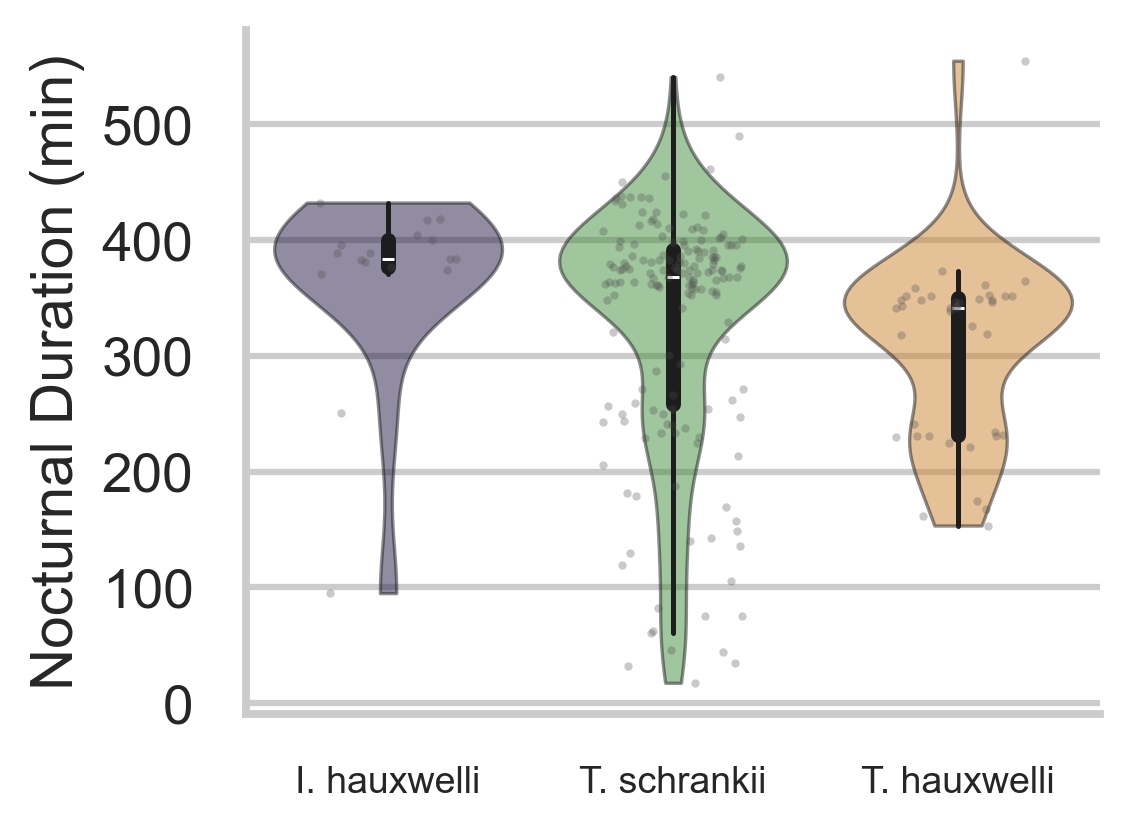

In [393]:
plot_species_violin(
    resumen_copy,
    value_col='avg_duracion_nocturnal',
    ylabel='Nocturnal Duration (min)',
    filename='Nocturnal-Bout_3species.png'
)

## K. Optional model diagnostics

These figures are not required by the ecological summaries but document how
the post-processing redistributes events, where the BiLSTM is most uncertain,
and how the latent BiLSTM activations cluster the predicted classes.


In [394]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

CLU_DIR = Path("figures/supplementary4/decision_clustering")
CLU_DIR.mkdir(parents=True, exist_ok=True)

n_days, T, two_h = hidden_all.shape
H = hidden_all.reshape(-1, two_h)
y_pred = preds_all.reshape(-1)
pr = probs_all.reshape(-1, NUM_CLASSES)

minute_idx = np.tile(np.arange(T), n_days)
day_idx    = np.repeat(np.arange(n_days), T)
arch_arr   = np.array([a for a, _, _ in all_days])
date_arr   = np.array([str(d) for _, d, _ in all_days])
arch_per_min = arch_arr[day_idx]
date_per_min = date_arr[day_idx]
susp_per_min = inference_df["suspicious_nocturnal"].to_numpy()

rng = np.random.default_rng(42)
n_total = H.shape[0]
sample_n = min(50_000, n_total)
sel = rng.choice(n_total, size=sample_n, replace=False)
Hs   = H[sel]
yp   = y_pred[sel]
prs  = pr[sel]
susp = susp_per_min[sel]
arch_s = arch_per_min[sel]
date_s = date_per_min[sel]
mins_s = minute_idx[sel]

pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(Hs)
print(f"PCA explained variance: {pca.explained_variance_ratio_.round(3).tolist()}")

n_clusters = NUM_CLASSES + 1
km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit(Z)
labels_km = km.labels_

# 1) PCA by predicted class
fig, ax = plt.subplots(figsize=(7, 6))
for c in [0, 1, 2]:
    m = yp == c
    ax.scatter(Z[m, 0], Z[m, 1], s=3, alpha=0.4, c=COLORS[c], label=LABELS[c])
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(markerscale=4)
ax.set_title("BiLSTM latent space — colour: predicted class")
fig.tight_layout(); fig.savefig(CLU_DIR / "latent_space_pca_by_predicted_label.png", dpi=200)
plt.close(fig)

# 2) PCA by KMeans cluster
fig, ax = plt.subplots(figsize=(7, 6))
for k in range(n_clusters):
    m = labels_km == k
    ax.scatter(Z[m, 0], Z[m, 1], s=3, alpha=0.4, label=f"cluster {k}")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(markerscale=4)
ax.set_title(f"BiLSTM latent space — KMeans (k={n_clusters})")
fig.tight_layout(); fig.savefig(CLU_DIR / "latent_space_pca_by_cluster.png", dpi=200)
plt.close(fig)

# 3) Suspicious Nocturnal highlighted
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(Z[:, 0], Z[:, 1], s=3, alpha=0.15, c="lightgrey", label="all minutes")
m = susp.astype(bool)
ax.scatter(Z[m, 0], Z[m, 1], s=6, alpha=0.85, c=COLORS[2],
           label="suspicious Nocturnal (flagged)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(markerscale=3)
ax.set_title("Suspicious Nocturnal predictions in latent space")
fig.tight_layout(); fig.savefig(CLU_DIR / "suspicious_nocturnal_latent_space.png", dpi=200)
plt.close(fig)

# Sample latent table
latent_sample = pd.DataFrame({
    "PC1": Z[:, 0], "PC2": Z[:, 1], "cluster": labels_km,
    "archivo": arch_s, "date": date_s, "minute_of_day": mins_s,
    "prediccion": yp, "prediccion_label": [LABEL_MAP[int(v)] for v in yp],
    "prob_nocturnal": prs[:, 0], "prob_off": prs[:, 1], "prob_on": prs[:, 2],
    "suspicious_nocturnal": susp,
})
latent_sample.to_csv("supplementary4_hidden_state_sample.csv", index=False)
print("Latent sample saved to supplementary4_hidden_state_sample.csv (rows:", len(latent_sample), ")")


PCA explained variance: [0.26899999380111694, 0.17299999296665192]
Latent sample saved to supplementary4_hidden_state_sample.csv (rows: 50000 )


In [395]:
hidden_dim = H.shape[1]
profiles = np.zeros((hidden_dim, 4))
for c in [0, 1, 2]:
    m = y_pred == c
    if m.any():
        profiles[:, c] = H[m].mean(axis=0)
m_susp = susp_per_min.astype(bool)
if m_susp.any():
    profiles[:, 3] = H[m_susp].mean(axis=0)

n_unit_clusters = min(5, hidden_dim)
km_u = KMeans(n_clusters=n_unit_clusters, random_state=42, n_init=10).fit(profiles)
order = np.argsort(km_u.labels_)

cols = ["Nocturnal", "Off", "On", "suspicious_Nocturnal"]
fig, ax = plt.subplots(figsize=(6, 10))
im = ax.imshow(profiles[order], aspect="auto", cmap="coolwarm")
ax.set_xticks(range(4)); ax.set_xticklabels(cols, rotation=20)
ax.set_ylabel("Hidden unit (clustered)"); ax.set_title("Mean activation per hidden unit")
fig.colorbar(im, ax=ax, label="mean activation")
fig.tight_layout(); fig.savefig(CLU_DIR / "hidden_unit_activation_heatmap.png", dpi=200)
plt.close(fig)

fig, ax = plt.subplots(figsize=(7, 5))
for k in range(n_unit_clusters):
    members = profiles[km_u.labels_ == k]
    ax.plot(range(4), members.mean(axis=0), marker="o",
            label=f"cluster {k} (n={len(members)})")
ax.set_xticks(range(4)); ax.set_xticklabels(cols, rotation=20)
ax.set_ylabel("Mean activation"); ax.set_title("Unit-cluster activation profiles"); ax.legend()
fig.tight_layout(); fig.savefig(CLU_DIR / "unit_cluster_activation_profiles.png", dpi=200)
plt.close(fig)

unit_df = pd.DataFrame(profiles, columns=cols)
unit_df["unit_index"] = np.arange(hidden_dim)
unit_df["cluster"] = km_u.labels_
unit_df.to_csv("supplementary4_hidden_unit_profiles.csv", index=False)
print("Hidden-unit profiles saved to supplementary4_hidden_unit_profiles.csv")


Hidden-unit profiles saved to supplementary4_hidden_unit_profiles.csv


In [396]:
from matplotlib.patches import Patch
import re

POSTPROC_DIR = Path("figures/supplementary4/postprocessing_examples/raw_vs_postprocessed")
(POSTPROC_DIR / "corrected").mkdir(parents=True, exist_ok=True)
(POSTPROC_DIR / "no_correction").mkdir(parents=True, exist_ok=True)
(POSTPROC_DIR / "random").mkdir(parents=True, exist_ok=True)


def safe_name(text):
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(text))


def iter_segments(values):
    change = np.where(np.diff(values) != 0)[0] + 1
    starts = np.concatenate([[0], change])
    ends = np.concatenate([change, [len(values)]])
    return zip(starts, ends)


def draw_state_background(ax, minute, states, alpha=0.18):
    for s, e in iter_segments(states):
        state = int(states[s])
        ax.axvspan(minute[s], minute[e - 1] + 1, color=COLORS[state], alpha=alpha)


def draw_corrected_outline(ax, minute, corrected_mask):
    corrected_mask = corrected_mask.astype(int)
    if corrected_mask.sum() == 0:
        return
    change = np.where(np.diff(corrected_mask) != 0)[0] + 1
    starts = np.concatenate([[0], change])
    ends = np.concatenate([change, [len(corrected_mask)]])
    for s, e in zip(starts, ends):
        if corrected_mask[s] == 0:
            continue
        ax.axvspan(minute[s], minute[e - 1] + 1, fill=False, edgecolor=COLORS[2], linewidth=1.5, hatch="//")


def plot_raw_vs_postprocessed_day(g, out_path, title):
    minute = g["minute_of_day"].to_numpy()
    raw_pred = g["prediccion"].to_numpy()
    post_pred = g["postprocessed_prediction"].to_numpy()
    corrected = raw_pred != post_pred

    fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True, constrained_layout=True)
    for ax, states, panel_title in zip(axes, [raw_pred, post_pred], ["Raw prediction", "Post-processed prediction"]):
        draw_state_background(ax, minute, states)
        draw_corrected_outline(ax, minute, corrected)
        ax.plot(minute, g["egg_temperature"], color="black", lw=1.0, label="egg")
        ax.plot(minute, g["ambient_temperature"], color="grey", lw=0.8, label="ambient")
        ax.set_xlim(0, 1439)
        ax.set_ylabel("°C")
        ax.set_title(panel_title)
        handles = [Patch(color=COLORS[i], alpha=0.4, label=LABELS[i]) for i in [0, 1, 2]]
        handles.append(Patch(facecolor="white", edgecolor=COLORS[2], hatch="//", label="corrected Nocturnal→On"))
        ax.legend(handles=handles + ax.get_legend_handles_labels()[0], loc="upper right", fontsize=8, ncol=2)
    axes[-1].set_xlabel("minute of day")
    fig.suptitle(title)
    fig.savefig(out_path, dpi=180)
    plt.close(fig)


corrected_day_counts = (
    inference_df.assign(corrected=(inference_df["prediccion"] != inference_df["postprocessed_prediction"]))
    .groupby(["archivo", "date"])["corrected"]
    .sum()
    .reset_index(name="corrected_minutes")
    .sort_values(["corrected_minutes", "archivo", "date"], ascending=[False, True, True])
)

corrected_days = corrected_day_counts[corrected_day_counts["corrected_minutes"] > 0].head(10)
no_correction_days = corrected_day_counts[corrected_day_counts["corrected_minutes"] == 0].head(5)
all_day_keys = inference_df.groupby(["archivo", "date"]).size().index.tolist()
rng = np.random.default_rng(0)
random_pick = rng.choice(len(all_day_keys), size=min(5, len(all_day_keys)), replace=False)

for _, row in corrected_days.iterrows():
    a, d = row["archivo"], row["date"]
    g = inference_df[(inference_df["archivo"] == a) & (inference_df["date"] == d)]
    out = POSTPROC_DIR / "corrected" / f"{safe_name(a)}_{safe_name(d)}.png"
    plot_raw_vs_postprocessed_day(g, out, f"{a} — {d} (corrected minutes: {int(row['corrected_minutes'])})")

for _, row in no_correction_days.iterrows():
    a, d = row["archivo"], row["date"]
    g = inference_df[(inference_df["archivo"] == a) & (inference_df["date"] == d)]
    out = POSTPROC_DIR / "no_correction" / f"{safe_name(a)}_{safe_name(d)}.png"
    plot_raw_vs_postprocessed_day(g, out, f"{a} — {d} (no correction)")

for idx in random_pick:
    a, d = all_day_keys[idx]
    g = inference_df[(inference_df["archivo"] == a) & (inference_df["date"] == d)]
    corrected_minutes = int((g["prediccion"] != g["postprocessed_prediction"]).sum())
    out = POSTPROC_DIR / "random" / f"{safe_name(a)}_{safe_name(d)}.png"
    plot_raw_vs_postprocessed_day(g, out, f"{a} — {d} (random, corrected minutes: {corrected_minutes})")

print("Paired raw-vs-postprocessed figures saved under", POSTPROC_DIR)

Paired raw-vs-postprocessed figures saved under figures\supplementary4\postprocessing_examples\raw_vs_postprocessed


## L. Quality checks

Final asserts and a markdown QA report at
`prometeo/supplementary4_QA_report.md`.


In [397]:
assert "BiLSTMModel" in globals()
assert ACTIVE_FEATURES == EXPECTED_FEATURES
assert INPUT_SIZE == 5
assert len(ACTIVE_FEATURES) == INPUT_SIZE
assert X_arr.shape == (len(all_days), 1440, INPUT_SIZE)
assert preds_all.shape == (len(all_days), 1440)
assert set(np.unique(preds_all)).issubset({0, 1, 2})
assert set(np.unique(inference_df["postprocessed_prediction"])) .issubset({0, 1, 2})
assert COLORS == {0: "#333E48", 1: "#535AA6", 2: "#E28342"}
assert LABELS == {0: "Nocturnal", 1: "Off", 2: "On"}
assert "prediccion" in inference_df.columns
assert "postprocessed_prediction" in inference_df.columns
assert not inference_df["prediccion"].equals(inference_df["postprocessed_prediction"]) or corrected_count == 0

n_days = len(all_days)
n_removed = int((diag_df["kept_or_removed"] == "removed").sum())
days_detected = len(diag_df)
removal_pct = (100.0 * n_removed / days_detected) if days_detected else 0.0
n_susp_events = int(events_diag["suspicious_nocturnal"].sum())
n_noc_events = int((events_diag["state_label"] == "Nocturnal").sum())
corrected_minutes = int((inference_df["prediccion"] != inference_df["postprocessed_prediction"]).sum())

qa = f"""# Supplementary 4 — QA Report (generated by the notebook)

- Active model        : {feature_schema['active_model']}
- Model loaded from   : `{MODEL_PATH}`
- Active features ({INPUT_SIZE}): {ACTIVE_FEATURES}
- Hidden size / layers: {HIDDEN_SIZE} / {NUM_LAYERS}
- Architecture        : BiLSTM only
- Label map           : {LABEL_MAP}
- Days detected       : {days_detected}
- Days kept           : {n_days}
- Days removed        : {n_removed}
- Removal percent     : {removal_pct:.1f}%
- Raw Nocturnal events: {n_noc_events}
- Suspicious Nocturnal events: {n_susp_events}
- Nocturnal events reclassified as On: {corrected_count}
- Protected night Nocturnal events kept: {protected_nocturnal_kept}
- Minutes reclassified from Nocturnal to On: {corrected_minutes}
- Delta On minutes    : {delta_on_minutes}
- Delta Nocturnal minutes: {delta_nocturnal_minutes}

## Why the correction was added

Cross-validation showed true On was predicted as Nocturnal in approximately 4–6% of minute-level cases across folds. The post-processing layer is therefore used only for diagnostic comparison of short isolated Nocturnal predictions and likely On–Nocturnal class-confusion segments during inference.

## Rules used

- Rule A — short daytime Nocturnal island
- Rule B — short Nocturnal segment surrounded by On
- Rule C — short low-confidence Nocturnal with On as the second-highest class probability
- Rule D — daytime short + low confidence
- Main night interval protection (00:00–06:00 and 18:00–24:00), except for very short segments surrounded by On

## Confirmations

- [x] The active model is `Model_C_time_scaled`.
- [x] Input size is 5.
- [x] Feature order follows the schema exactly.
- [x] The architecture is BiLSTM only.
- [x] Incomplete days were removed under strict calendar-day blocking.
- [x] Raw predictions remain in `prediccion`.
- [x] `suspicious_nocturnal` remains a separate diagnostic flag.
- [x] `postprocessed_prediction` and `postprocessed_label` remain separate from the raw prediction columns.
- [x] The correction is heuristic and should be reviewed manually before interpretation.
- [x] Figures use the fixed colour map (Nocturnal #333E48, Off #535AA6, On #E28342).

## Outputs

- `resultados_supplementary4_inference_raw.csv`
- `resultados_supplementary4_inference_postprocessed.csv`
- `eventos_supplementary4_raw.csv`
- `eventos_supplementary4_diagnostics.csv`
- `eventos_supplementary4_postprocessed.csv`
- `supplementary4_nocturnal_to_on_correction_summary.csv`
- `nest_attentiveness_raw.csv`
- `nest_attentiveness_postprocessed.csv`
- `nest_attentiveness_raw_vs_postprocessed.csv`
- `prometeo/supplementary4_day_blocking_QA.csv`
- `figures/supplementary4/error_analysis/`
- `figures/supplementary4/decision_clustering/`
- `figures/supplementary4/postprocessing_examples/raw_vs_postprocessed/`
"""

Path("prometeo").mkdir(exist_ok=True)
Path("prometeo/supplementary4_QA_report.md").write_text(qa, encoding="utf-8")
print("QA report written to prometeo/supplementary4_QA_report.md")

QA report written to prometeo/supplementary4_QA_report.md
